In [50]:
import re
from operator import index

import numpy as np
import pandas as pd
from pprint import pprint

# BERTopic imports
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.utils.fixes import np_version
from sympy.stats.sampling.sample_numpy import numpy
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

# Plotting tools
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

# Warnings
import warnings

from IPython.display import display, HTML
from matplotlib_venn import venn3, venn3_circles, venn3_unweighted
from matplotlib_venn import venn2
from matplotlib_venn.layout.venn3 import DefaultLayoutAlgorithm
from matplotlib_venn.layout.venn2 import DefaultLayoutAlgorithm as DefaultLayoutAlgorithm_V2 

import itertools


warnings.filterwarnings("ignore")
from IPython.display import display, Markdown, Latex


def show_topic_statistics(df: pd.DataFrame):
    res = df.groupby(["BERTopic_Topic", "BERTopic_Topic_Label", "BERTopic_openai"]).agg(count=("Abstract", "count"))
    display(res)
    return res



def compare_data_frames(df1, df2, df1_name, df2_name):
    print(f"There are {len(df1)} in series {df1_name}, and {len(df2)} in series {df2_name}")

    # values in s1 but not in s2
    only_df1 = df1['Abstract'][~df1['Abstract'].isin(df2['Abstract'])]
    
    # values in s2 but not in s1
    only_df2 = df2['Abstract'][~df2['Abstract'].isin(df1['Abstract'])]
    
    # only_s1 = pd.Series(list(set(topic_0_it_2_df) - set(topic_0_it_3_df)))
    # only_s2 = pd.Series(list(set(topic_0_it_3_df) - set(topic_0_it_2_df)))
    print(f"{len(only_df1)} Titles only in {df1_name} but not in {df2_name}:")
    if len(only_df1) > 0:
        display(only_df1.index)
        display(df1.loc[only_df1.index])
    print(f"{len(only_df2)} Titles only in {df2_name} but not {df1_name}:")
    if len(only_df2) > 0:
        display(only_df2.index)
        display(df2.loc[only_df2.index])
    
    return df1.loc[only_df1.index], df2.loc[only_df2.index]
  
def plot_venn(series, series_names):
    fig, axes = plt.subplots(figsize=(4,4))
    #fig.suptitle(f"Comparing {','.join(series_names)}")
    fixed_subsets=tuple(1 for i in range(len(series)*(len(series)-1)+1))
    if len(series) ==2:
        venn2(subsets=[set(s) for s in series], set_labels=series_names, layout_algorithm=DefaultLayoutAlgorithm_V2(fixed_subset_sizes=fixed_subsets), ax=axes)
    else:
        venn3(subsets=[set(s) for s in series], set_labels=series_names, layout_algorithm=DefaultLayoutAlgorithm(fixed_subset_sizes=fixed_subsets), ax=axes)
    
    plt.show()


<style>

figcaption{
    background: center;
}

</style>

# Trainings iterations

The following criteria is applied during the reduction of documents (for inclusion criteria only the title is considered):

| Criteria | Type      | Description                                                                                                            |
|----------|-----------|------------------------------------------------------------------------------------------------------------------------|
| $i_1$    | Inclusion | Study explicitly targets software architecture, design pattern or other software design specific aspects               |
| $i_2$    | Inclusion | Study targets energy consumption/efficiency                                                                            |
| $e_1$    | Exclusion | The study is not peer-reviewed                                                                                         |
| $e_2$    | Exclusion | The study is not written in English                                                                                    |
| $e_3$    | Exclusion | The full text is not accessible from our institution                                                                   |
| $e_4$    | Exclusion | The study is not a primary, single, cohesive research contribution, including secondary studies such as: <br> Systematic Literature Reviews (SLRs), Systematic Mapping Studies (SMS), surveys, as well as conference proceedings volumes, edited books, editorials, or introductory papers. |



## Iteration 1 
The following results were  generated during the first iteration:

In [51]:
it_01 = pd.read_csv("../output/02-BERTopic/bertopic_1.csv", converters={'Local File': str}, index_col=0)
it_10_statistics = show_topic_statistics(it_01)
it_10_statistics.to_csv("bertopic_1_statistics.csv")

,,,count
BERTopic_Topic,BERTopic_Topic_Label,BERTopic_openai,
-1,Outlier,Energy Efficient Software Architecture for Low Power Consumption,75
0,performance_multicore_power,High Performance and Energy Efficiency in Multicore Architectures,112
1,energy_software_energy consumption,Energy Efficiency in Software Development and Consumption,48
2,green_software_sustainability,Green Software Engineering for Sustainable Development,42
3,network_sensor_wireless,Wireless Sensor Network Design and Energy Efficiency,33
4,mobile_energy_consumption,Energy Efficiency in Mobile Applications through Code Smell Analysis and Architectural Design,26
5,energy_embedded_software,Energy Optimization in Embedded Software Design,24
6,design patterns_patterns_pattern,Energy Efficiency in Software Design Patterns,15
7,sensor_data_power,Intelligent Energy Management and Monitoring Systems in Smart Infrastructure,14


> For the Outlier Topic we decided to generate an open ai label as well. 

<figure>
    <img src="../output/02-BERTopic/1/topic_distribution.png" height="200px" alt="Topic Distribution">
    <figcaption>Distribution of the afore mentioned topics (excluding the outliers)</figcaption>
</figure>


In the first run BERTopic was creating a topic for the following keywords based on `merged.csv`:
```
building (0.13), buildings (0.10), thermal (0.09), comfort (0.08), design (0.07), simulation (0.07), climate (0.06), environmental (0.06), energy (0.06), built (0.05)
```
![Topic Word Cloud](../output/02-BERTopic/1/word_cloud_8.png)

The results have been saved into the file `../output/02-BERTopic/bertopic_1.csv`.

### Exclusion
In order to remove this noise, i am going to check all documents from this topic and remove them from the dataset.
The following paper have been removed:

In [52]:
it_01[it_01['BERTopic_Topic'] == 8]

,Title,DOI,Source,Year,Source title,Cited by,Document Type,Abstract,Author full names,Index Keywords,...,BERTopic_Topic_Label,BERTopic_Probability,BERTopic_Count,BERTopic_Name,BERTopic_Representation,BERTopic_main,BERTopic_openai,BERTopic_aspect1,BERTopic_aspect2,BERTopic_Representative_Docs
83,Building a Net Zero Energy Home: A Case Study ...,NaN,Scopus,2023,ZEMCH International Conference,0.0,Conference paper,"Human activity, mainly in the construction sec...","Cárdenas-Ramírez, Juan Pablo; Romero Quidel, ...",NaN,...,building_buildings_thermal,1.0,10,8_building_buildings_thermal_comfort,"['building', 'buildings', 'thermal', 'comfort'...","['buildings', 'building', 'energy efficiency',...",Energy Efficiency and Thermal Comfort in Build...,"['building', 'buildings', 'thermal', 'comfort'...","['buildings', 'energy efficiency', 'climate', ...",['This paper comes in order to evaluate the in...
84,Building’s energy performances and climate: Ca...,NaN,Scopus,2018,International Journal of Civil Engineering and...,0.0,Article,This paper comes in order to evaluate the infl...,"Cheikhi, Wiçal; Nounah, Abderrahmane; Baba, ...",NaN,...,building_buildings_thermal,1.0,10,8_building_buildings_thermal_comfort,"['building', 'buildings', 'thermal', 'comfort'...","['buildings', 'building', 'energy efficiency',...",Energy Efficiency and Thermal Comfort in Build...,"['building', 'buildings', 'thermal', 'comfort'...","['buildings', 'energy efficiency', 'climate', ...",['This paper comes in order to evaluate the in...
103,Coupling dynamic energy and daylighting simula...,NaN,Scopus,2015,Building Simulation Applications,0.0,Conference paper,"In tropical developing countries, the consider...","Fuica, Gerardo Erich Saelzer; Soto, Emily Vargas",Architectural design; Developing countries; En...,...,building_buildings_thermal,1.0,10,8_building_buildings_thermal_comfort,"['building', 'buildings', 'thermal', 'comfort'...","['buildings', 'building', 'energy efficiency',...",Energy Efficiency and Thermal Comfort in Build...,"['building', 'buildings', 'thermal', 'comfort'...","['buildings', 'energy efficiency', 'climate', ...",['This paper comes in order to evaluate the in...
106,Data center energy demand: What got us here wo...,10.1109/MS.2016.53,Scopus,2016,IEEE Software,12.0,Article,Given environmentalism's rising tide and incre...,"Noureddine, Adel; Woods, Eoin; Bashroush, Rabih",Energy efficiency; Software architecture; Soft...,...,building_buildings_thermal,1.0,10,8_building_buildings_thermal_comfort,"['building', 'buildings', 'thermal', 'comfort'...","['buildings', 'building', 'energy efficiency',...",Energy Efficiency and Thermal Comfort in Build...,"['building', 'buildings', 'thermal', 'comfort'...","['buildings', 'energy efficiency', 'climate', ...",['This paper comes in order to evaluate the in...
120,Designing a Qualitative Pre-diagnosis Model fo...,10.1007/978-3-031-43559-1_9,Scopus,2023,Environmental Science and Engineering,0.0,Conference paper,In a very early stage of implementation of a c...,"Lopes, Nuno Alberto Ferreira; Lopes, Sergio ...",Air quality; Benchmarking; Digital storage; En...,...,building_buildings_thermal,1.0,10,8_building_buildings_thermal_comfort,"['building', 'buildings', 'thermal', 'comfort'...","['buildings', 'building', 'energy efficiency',...",Energy Efficiency and Thermal Comfort in Build...,"['building', 'buildings', 'thermal', 'comfort'...","['buildings', 'energy efficiency', 'climate', ...",['This paper comes in order to evaluate the in...
256,Micro-Climate Building Context Visualization: ...,NaN,Scopus,2023,Proceedings of the International Conference on...,1.0,Conference paper,Residential buildings are responsible for a co...,"Mostafavi, Fatemeh; Khademi, Seyran",NaN,...,building_buildings_thermal,1.0,10,8_building_buildings_thermal_comfort,"['building', 'buildings', 'thermal', 'comfort'...","['buildings', 'building', 'energy efficiency',...",Energy Efficiency and Thermal Comfort in Build...,"['building', 'buildings'


| Index | Title                                                                                                                                                                                                              | Reason                                |
|-------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|---------------------------------------|
| 83    | Building a Net Zero Energy Home: A Case Study with Wikihouse Prototype in Chile                                                                                                                                    | Not satisfying any inclusion criteria |
| 84    | Building’s energy performances and climate: Case of the rammed earth buildings in Morocco                                                                                                                          | Not satisfying any inclusion criteria |
| 103   | Coupling dynamic energy and daylighting simulations for complex fenestration systems simulation experiences for the thermal performance improvement of naturally ventilated classroom in the tropics of Costa Rica | Not satisfying any inclusion criteria |
| 120   | Designing a Qualitative Pre-diagnosis Model for the Evaluation of Radon Potential in Indoor Environments                                                                                                           | Not satisfying any inclusion criteria |
| 256   | Micro-Climate Building Context Visualization: A pipeline for generating buildings’ environmental context maps using numerical simulation data                                                                      | Not satisfying any inclusion criteria |
| 289   | Optimum utilization of daylighting in office buildings                                                                                                                                                             | Not satisfying any inclusion criteria |
| 315   | Reaching Near-Zero Environmental Impact in Heritage Buildings: The Case of the Wine Cellar of Rocafort de Queralt                                                                                                  | Not satisfying any inclusion criteria |
| 334   | Simulation-based daylighting design education and technical support                                                                                                                                                | Not satisfying any inclusion criteria |
| 385   | Towards carbon-neutral construction: Integrating BIM and energy analysis for sustainable design decision-making                                                                                                    | Not satisfying any inclusion criteria |

Keep:

| Index | Title                                                                                                                                                                                                               | Reason                                                        |
|-------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|---------------------------------------------------------------|
| 106   | Data center energy demand: What got us here won't get us there                                                                                                                                                      | Satisfying both inclusion criteria in abstract (rather short) |



## Iteration 2
With removing 9 papers from the list the set is reduced down to 390 papers.
This results in just two topics to be chosen during training. 
There are errors occurring in this situation with creating the diagrams, therefore i decreased:
* min_cluster_size: 10 -> 8 -> 7
* n_components: 5 -> 3 -> 3

The results are displayed in the file `../output/02-BERTopic/bertopic_2.csv`:

In [53]:
it_02 = pd.read_csv("../output/02-BERTopic/bertopic_2.csv", converters={'Local File': str}, index_col=0)
show_topic_statistics(it_02)

,,,count
BERTopic_Topic,BERTopic_Topic_Label,BERTopic_openai,
-1,Outlier,Energy-Efficient Software Design and Consumption Analysis,37
0,performance_multicore_memory,Performance Optimization in Multicore Architectures Through Advanced Memory Management and Energy Efficiency Techniques,112
1,energy_software_energy consumption,Energy Efficiency in Software Development and Consumption,55
2,green_software_sustainability,Green Software Engineering and Sustainability Practices,43
3,network_sensor_wireless,Wireless Sensor Networks and Energy Efficiency in Monitoring Applications,29
4,mobile_energy_consumption,Energy Efficiency in Mobile Application Development,28
5,control_temperature_sensor,Energy Monitoring and Management Systems in Smart Buildings,17
6,design patterns_patterns_pattern,Impact of Design Patterns on Software Energy Consumption,15
7,synthesis_design_systems,Energy-Efficient Design and Synthesis for Embedded Systems,12


,,,count
BERTopic_Topic,BERTopic_Topic_Label,BERTopic_openai,
-1,Outlier,Energy-Efficient Software Design and Consumption Analysis,37
0,performance_multicore_memory,Performance Optimization in Multicore Architectures Through Advanced Memory Management and Energy Efficiency Techniques,112
1,energy_software_energy consumption,Energy Efficiency in Software Development and Consumption,55
2,green_software_sustainability,Green Software Engineering and Sustainability Practices,43
3,network_sensor_wireless,Wireless Sensor Networks and Energy Efficiency in Monitoring Applications,29
4,mobile_energy_consumption,Energy Efficiency in Mobile Application Development,28
5,control_temperature_sensor,Energy Monitoring and Management Systems in Smart Buildings,17
6,design patterns_patterns_pattern,Impact of Design Patterns on Software Energy Consumption,15
7,synthesis_design_systems,Energy-Efficient Design and Synthesis for Embedded Systems,12



<figure>
    <img src="../output/02-BERTopic/2/topic_distribution.png" height="250px" alt="Topic Distribution">
    <figcaption>Distribution of the afore mentioned topics (excluding the outliers)</figcaption>
</figure>

### Comparison of Topic 0 (Iteration 1 and 2)
Since the topic 0 from iteration 0 and 1 seems to be equivalent so it needs further investigation.

**Comparing iteration 1 and 2 regarding topic 0**

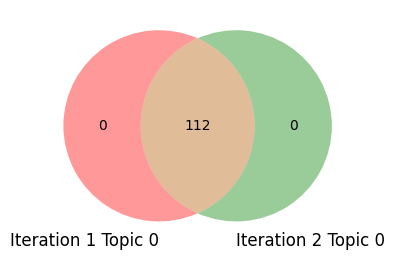

There are 112 in series Iteration 1 Topic 0, and 112 in series Iteration 2 Topic 0
0 Titles only in Iteration 1 Topic 0 but not in Iteration 2 Topic 0:
0 Titles only in Iteration 2 Topic 0 but not Iteration 1 Topic 0:


(Empty DataFrame
 Columns: [index, Title, DOI, Source, Year, Source title, Cited by, Document Type, Abstract, Author full names, Index Keywords, Author Keywords, Volume, Language of Original Document, Publisher, Conference name, Conference code, ISBN, ieee_file, acm_file, Abstract_clean, BERTopic_Topic, BERTopic_Topic_Label, BERTopic_Probability, BERTopic_Count, BERTopic_Name, BERTopic_Representation, BERTopic_main, BERTopic_openai, BERTopic_aspect1, BERTopic_aspect2, BERTopic_Representative_Docs]
 Index: []
 
 [0 rows x 32 columns],
 Empty DataFrame
 Columns: [level_0, index, Title, DOI, Source, Year, Source title, Cited by, Document Type, Abstract, Author full names, Index Keywords, Author Keywords, Volume, Language of Original Document, Publisher, Conference name, Conference code, ISBN, ieee_file, acm_file, Abstract_clean, BERTopic_Topic, BERTopic_Topic_Label, BERTopic_Probability, BERTopic_Count, BERTopic_Name, BERTopic_Representation, BERTopic_main, BERTopic_openai, BERTopic_aspec

In [54]:
iteration1_df = pd.read_csv(f"../output/02-BERTopic/bertopic_1.csv", converters={'Local File': str}, index_col=0)
iteration2_df = pd.read_csv(f"../output/02-BERTopic/bertopic_2.csv", converters={'Local File': str}, index_col=0)


topic_0_it_1_df = it_01[it_01["BERTopic_Topic"] == 0].reset_index()
topic_0_it_2_df = it_02[it_02["BERTopic_Topic"] == 0].reset_index()

display(Markdown('**Comparing iteration 1 and 2 regarding topic 0**'))
plot_venn([topic_0_it_1_df['Abstract'], topic_0_it_2_df['Abstract']], ["Iteration 1 Topic 0", "Iteration 2 Topic 0"])
compare_data_frames(topic_0_it_1_df, topic_0_it_2_df, "Iteration 1 Topic 0", "Iteration 2 Topic 0")

There is no difference between iteration 0 and 1 regarding the documents being classified but the topic label changed from `performance_multicore_power` to `performance_multicore_memory`.

Additionally, to the Outlier-Topics open ai label changed from `Energy-Efficient Software Architecture for Low Power Consumption in Embedded Systems` to `Energy-Efficient Software Design and Development Techniques`

### Exclusion
In order to reduce the list of documents even further, we are going to check the documents listed in topic `3` with the label `Wireless Sensor Networks and Energy Efficiency in Monitoring Systems (network_sensor_wireless)`.

In [55]:
display(it_02[it_02['BERTopic_Topic'] == 3])

,index,Title,DOI,Source,Year,Source title,Cited by,Document Type,Abstract,Author full names,...,BERTopic_Topic_Label,BERTopic_Probability,BERTopic_Count,BERTopic_Name,BERTopic_Representation,BERTopic_main,BERTopic_openai,BERTopic_aspect1,BERTopic_aspect2,BERTopic_Representative_Docs
8,8,A Comparative Study of Software Architectures ...,10.1109/IoTaIS53735.2021.9628703,IEEE,2021,2021 IEEE International Conference on Internet...,2.0,IEEE Conferences,The Internet of Things (IoT) is an area that h...,"S. du Plessis; N. Correia; Correia, Noélia S...",...,network_sensor_wireless,0.045936,29,3_network_sensor_wireless_networks,"['network', 'sensor', 'wireless', 'networks', ...","['sensor network', 'sensor networks', 'wireles...",Wireless Sensor Networks and Energy Efficiency...,"['network', 'sensor', 'wireless', 'networks', ...","['sensor network', 'iot', 'protocols', '5g', '...",['This paper presents a collaborative networki...
39,39,Accurate power-aware simulation of wireless se...,10.1145/1868521.1868529,Scopus,2010,NaN,4.0,Conference paper,"In this paper, we present a methodology to est...","Möstl, Georg; Müller, Gerhard; Hagelauer, Ri...",...,network_sensor_wireless,0.256860,29,3_network_sensor_wireless_networks,"['network', 'sensor', 'wireless', 'networks', ...","['sensor network', 'sensor networks', 'wireles...",Wireless Sensor Networks and Energy Efficiency...,"['network', 'sensor', 'wireless', 'networks', ...","['sensor network', 'iot', 'protocols', '5g', '...",['This paper presents a collaborative networki...
42,42,Advances in Computing and Communications - Fir...,NaN,Scopus,2011,Communications in Computer and Information Sci...,0.0,Conference review,The proceedings contain 274 papers. The topics...,NaN,...,network_sensor_wireless,0.525909,29,3_network_sensor_wireless_networks,"['network', 'sensor', 'wireless', 'networks', ...","['sensor network', 'sensor networks', 'wireles...",Wireless Sensor Networks and Energy Efficiency...,"['network', 'sensor', 'wireless', 'networks', ...","['sensor network', 'iot', 'protocols', '5g', '...",['This paper presents a collaborative networki...
53,53,An adaptive offloading framework for Android a...,10.1007/s11432-018-9749-8,Scopus,2019,Science China Information Sciences,47.0,Article,Mobile edge computing (MEC) provides a fresh o...,"Chen, Xing; Zhang, Ying; Liu, Bichun; Huang...",...,network_sensor_wireless,0.042512,29,3_network_sensor_wireless_networks,"['network', 'sensor', 'wireless', 'networks', ...","['sensor network', 'sensor networks', 'wireles...",Wireless Sensor Networks and Energy Efficiency...,"['network', 'sensor', 'wireless', 'networks', ...","['sensor network', 'iot', 'protocols', '5g', '...",['This paper presents a collaborative networki...
71,71,Assessment of the Reliability of Wireless Sens...,10.1007/s10559-025-00753-3,Scopus,2025,Cybernetics and Systems Analysis,0.0,Article,"Based on the analyzed sources, it is establish...","Skorobohatko, Stanislav; Fesenko, Herman; Y...",...,network_sensor_wireless,1.000000,29,3_network_sensor_wireless_networks,"['network', 'sensor', 'wireless', 'networks', ...","['sensor network', 'sensor networks', 'wireles...",Wireless Sensor Networks and Energy Efficiency...,"['network', 'sensor', 'wireless', 'networks', ...","['sensor network', 'iot', 'protocols', '5g', '...",['This paper presents a collaborative networki...
81,81,Bluetooth and sensor networks: a reality check,10.1145/958491.958504,ACM Digital Library,2003,Proceedings of the 1st International Conferenc...,NaN,inproceedings,The current generation of sensor nodes rely on...,"Bonnet, Philippe; Leopold, Martin; Dydensbor...",...,network_sensor_wireless,1.000000,29,3_network_sensor_wireless_networks,"['network', 'sensor', 'wireless', 'networks', ...","['sensor network', 'sensor networks', 'wireles...",Wireless Sensor Networks and Energy Efficiency...,"['network', 'sensor', 'wireless', 'networks', ...","['sensor network', 'iot', 'protocols', '5g', '...",['This paper presents a collabora

| Index | Title                                                                                                                                                         | Reason                                |
|-------|---------------------------------------------------------------------------------------------------------------------------------------------------------------|---------------------------------------|
| 8     | A   Comparative Study of Software Architectures in Constrained Device IoT   Deployments                                                                       | Not satisfying $i_2$                  |
| 39    | Accurate   power-aware simulation of wireless sensor networks considering real-life   application code                                                        | Not satisfying any inclusion criteria |
| 42    | Advances in Computing and   Communications - First International Conference, ACC 2011, Proceedings                                                            | Exclusion Criteria $i_4$ applies      |
| 53    | An   adaptive offloading framework for Android applications in mobile edge   computing                                                                        | Not satisfying $i_2$                  |
| 71    | Assessment of the Reliability of   Wireless Sensor Networks for Forest Fire Monitoring Systems Considering Fatal   Combinations of Multiple Sensor Failures   | Not satisfying any inclusion criteria |
| 81    | Bluetooth   and sensor networks: a reality check                                                                                                              | Not satisfying any inclusion criteria |
| 107   | Demo:   Visual attention driven networking with smart glasses                                                                                                 | Not satisfying any inclusion criteria |
| 116   | Design of a 5G redcap onboard terminal for UAVs                                                                                                               | Not satisfying any inclusion criteria |
| 130   | Dynamic   urban evaluation routing protocol for enhanced vehicle ad hoc networks                                                                              | Not satisfying any inclusion criteria |
| 135   | EasiSHA: A reconfigurable node architecture for IoT based on joint design of software and hardware                                                            | Not satisfying any inclusion criteria |
| 146   | Enabling   densely-scalable low-power WSNs for shipping and industrial IoT                                                                                    | Not satisfying any inclusion criteria |
| 162   | Energy efficient assignment and deployment of tasks in structurally variable   infrastructures                                                                | Not satisfying any inclusion criteria |
| 164   | Energy efficient smart irrigation system based on 6LoWPAN                                                                                                     | Not satisfying any inclusion criteria |
| 205   | Guest   editorial                                                                                                                                             | Exclusion Criteria $i_4$ applies      |
| 228   | Internet of Wearable Things   Systems: Comprehensive Review                                                                                                   | Not satisfying any inclusion criteria |
| 251   | MAGIC:   Magnetic Resonant Coupling for Intra-body Communication                                                                                              | Not satisfying any inclusion criteria |
| 258   | Mine fire detection system based   on wireless sensor network                                                                                                 | Not satisfying any inclusion criteria |
| 278   | On   energy consumption of Wi-Fi access points                                                                                                                | Not satisfying any inclusion criteria |
| 306   | Principles and protocols for   power control in wireless ad hoc networks                                                                                      | Not satisfying any inclusion criteria |
| 320   | Research   on Collaborative Networking Method of 5G Slicing and WiFi6 in Substation   Scenarios                                                               | Not satisfying any inclusion criteria |
| 332   | Simulation of attacks for   security in wireless sensor network                                                                                               | Not satisfying any inclusion criteria |
| 373   | The   implementation of an adaptive data reduction technique for wireless sensor   networks                                                                   | Not satisfying any inclusion criteria |
| 394   | Virtual platform-based design   space exploration of power-efficient distributed embedded applications                                                        | Not satisfying any inclusion criteria |
| 397   | Wireless   Sensor Network Security                                                                                                                            | Not satisfying any inclusion criteria |
| 398   | Workshop on NExt-generation   applications of smarTphones (NEAT)                                                                                              | Not satisfying any inclusion criteria |




### Keep

| Index | Title                                                                                                                | Reason                                                                                              |
|-------|----------------------------------------------------------------------------------------------------------------------|-----------------------------------------------------------------------------------------------------|
| 94    | Comparing REST, SOAP, Socket and   gRPC in computation offloading of mobile applications: An energy cost   analysis  | Analyses the energy efficiency of software architecture/design decisions                            |
| 148   | Energy Consumption   of IoT Monitoring Software Architectures   in the Edge                                          | Analyses the energy efficiency of software architecture/design decisions in iot edge infrastructure | 
| 240   | JSEVAsync:   An Asynchronous Event-based Framework to Energy Saving on IoT Devices                                   | Analyses two architecture approaches in iot to enhance energy efficiency                            |
| 247   | Litearch: an energy-centric   software architecture for wireless sensor networks                                     | Software architecture for more energy efficiency in sensor networks                                 |




## Iteration 3
The third iteration operates on 366 rows resulting in the following topics (`bertopic_3.csv`):

In [56]:
it_03 = pd.read_csv("../output/02-BERTopic/bertopic_3.csv", converters={'Local File': str}, index_col=0)
it_03_statistics = show_topic_statistics(it_03)

,,,count
BERTopic_Topic,BERTopic_Topic_Label,BERTopic_openai,
0,energy_software_consumption,Energy Efficiency in Software Development and Design,246
1,performance_power_energy,High-Performance Energy-Efficient Multicore Architectures and Optimization Techniques,119



<figure>
    <img src="../output/02-BERTopic/3/topic_distribution.png" height="300px" alt="Topic Distribution">
    <figcaption>Distribution of the afore mentioned topics (excluding the outliers)</figcaption>
</figure>



The number of topics is drastically reduced down to two (without any outliers).
In order to have a more fine grained clustering we tried to adapt the parameters to get more topics.




### Comparison of Topic 0 (Iteration 2 and 3)
Since we had similar topics 0 for iteration 1 and 2, we are going to compare this iteration with the previous as well.

**Comparing iteration 2 and 3 regarding topic 0**

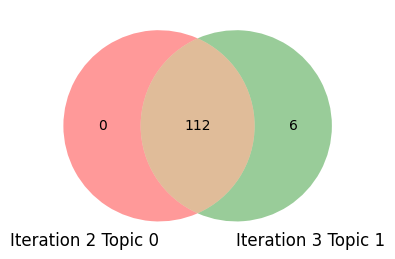

There are 112 in series Iteration 2 Topic 0, and 119 in series Iteration 3 Topic 1
0 Titles only in Iteration 2 Topic 0 but not in Iteration 3 Topic 1:
7 Titles only in Iteration 3 Topic 1 but not Iteration 2 Topic 0:


Index([4, 25, 28, 41, 43, 70, 91], dtype='int64')

,level_0,index,Title,DOI,Source,Year,Source title,Cited by,Document Type,Abstract,...,BERTopic_Topic_Label,BERTopic_Probability,BERTopic_Count,BERTopic_Name,BERTopic_Representation,BERTopic_main,BERTopic_openai,BERTopic_aspect1,BERTopic_aspect2,BERTopic_Representative_Docs
4,13,14,A Highly-efficient Lattice-based Post-Quantum ...,10.46586/tches.v2024.i2.130-153,Scopus,2024,IACR Transactions on Cryptographic Hardware an...,17.0,Article,"Lattice-Based Cryptography (LBC) schemes, like...",...,performance_power_energy,0.241769,119,1_performance_power_energy_multicore,"['performance', 'power', 'energy', 'multicore'...","['multicore architectures', 'processors', 'mul...",High-Performance Energy-Efficient Multicore Ar...,"['performance', 'power', 'energy', 'multicore'...","['multicore architectures', 'processor', 'core...",['The need for faster and more energy efficien...
25,75,80,Blockchain-based Decentralised Management of D...,10.14569/IJACSA.2024.01506144,Scopus,2024,International Journal of Advanced Computer Sci...,3.0,Article,With the recent impact of viral infections and...,...,performance_power_energy,0.241592,119,1_performance_power_energy_multicore,"['performance', 'power', 'energy', 'multicore'...","['multicore architectures', 'processors', 'mul...",High-Performance Energy-Efficient Multicore Ar...,"['performance', 'power', 'energy', 'multicore'...","['multicore architectures', 'processor', 'core...",['The need for faster and more energy efficien...
28,82,90,Compactrio based real time implementation of A...,10.4018/IJERTCS.2019040102,ACM Digital Library,2019,International Journal of Embedded and Real-Tim...,7.0,article,"For real-time embedded applications, several f...",...,performance_power_energy,0.244022,119,1_performance_power_energy_multicore,"['performance', 'power', 'energy', 'multicore'...","['multicore architectures', 'processors', 'mul...",High-Performance Energy-Efficient Multicore Ar...,"['performance', 'power', 'energy', 'multicore'...","['multicore architectures', 'processor', 'core...",['The need for faster and more energy efficien...
41,122,136,Efficient Software Architecture for IPSec Acce...,10.1109/DATE.2008.4484833,IEEE,2008,"2008 Design, Automation and Test in Europe",1.0,IEEE Conferences,Cryptographic accelerators and security proces...,...,performance_power_energy,0.245471,119,1_performance_power_energy_multicore,"['performance', 'power', 'energy', 'multicore'...","['multicore architectures', 'processors', 'mul...",High-Performance Energy-Efficient Multicore Ar...,"['performance', 'power', 'energy', 'multicore'...","['multicore architectures', 'processor', 'core...",['The need for faster and more energy efficien...
43,124,138,Efficient software architecture for IPSec acce...,10.1145/1403375.1403656,ACM Digital Library,2008,"Proceedings of the Conference on Design, Autom...",NaN,inproceedings,Cryptographic accelerators and security proces...,...,performance_power_energy,0.239162,119,1_performance_power_energy_multicore,"['performance', 'power', 'energy', 'multicore'...","['multicore architectures', 'processors', 'mul...",High-Performance Energy-Efficient Multicore Ar...,"['performance', 'power', 'energy', 'multicore'...","['multicore architectures', 'processor', 'core...",['The need for faster and more energy efficien...
70,223,242,K-stage pipelined bloom filter for packet clas...,10.1109/CSE.2009.408,Scopus,2009,NaN,7.0,Conference paper,A Bloom filter is a simple space-efficient ran...,...,performance_power_energy,0.345842,119,1_performance_power_energy_multicore,"['performance', 'power', 'energy', 'multicore'...","['multicore architectures', 'processors', 'mul...",High-Performance Energy-Efficient Multicore Ar...,"['performance', 'power', 'energy', 'multicore'...","['multicore architectures', 'processor', 'core...",['The need for faster and more energy efficien...
91,277,301,Power consumption aware software architecture ...,10.1109/TELSKS.2015.7357791,IEEE,2015,2015 12th International Conference on 

In [57]:
iteration3_df = pd.read_csv(f"../output/02-BERTopic/bertopic_3.csv", converters={'Local File': str}, index_col=0)
topic_1_it_3_df = iteration3_df[iteration3_df["BERTopic_Topic"] == 1].reset_index()

display(Markdown('**Comparing iteration 2 and 3 regarding topic 0**'))
plot_venn([topic_0_it_2_df['Abstract'], topic_1_it_3_df['Abstract']], ["Iteration 2 Topic 0", "Iteration 3 Topic 1"])

only_t0_it_2, only_t1_it_3 =compare_data_frames(topic_0_it_2_df, topic_1_it_3_df, "Iteration 2 Topic 0", "Iteration 3 Topic 1")
print()


### Iteration 3.1
For this, we did a small sub-iteration checking the topic count with applying the criteria for iteration 2 for this as well.
```
min_cluster_size: 7
n_components: 3
```

> We will keep these parameters for the following iterations

In [58]:
it_03_01 = pd.read_csv("../output/02-BERTopic/bertopic_3.1.csv", converters={'Local File': str}, index_col=0)
it_03_01_statistics = show_topic_statistics(it_03_01)

,,,count
BERTopic_Topic,BERTopic_Topic_Label,BERTopic_openai,
0,energy_software_consumption,Energy Efficiency in Software Development and Consumption,246
1,performance_energy_power,Hybrid Memory Architectures and Energy Optimization in Multicore Systems,112
2,bloom_security_filter,Power-efficient Security Architectures for Mobile and Network Applications,7


A new topic 2 (bloom_security_filter) has been found. Since the number of documents in topic 1 (performance_energy_power) has been reduced, we assume the new topic has been built from this topic. The following analysis evaluates this:

**Comparing iteration 3 and 3.1 regarding topics 1 and new topic 2 of iteration 3.1**

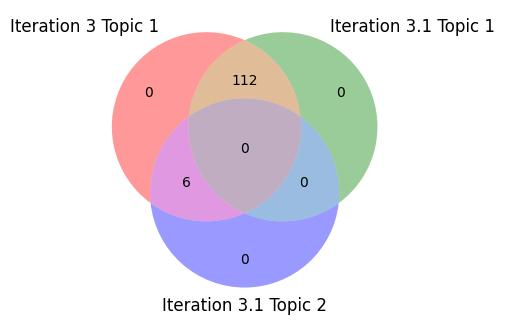

In [59]:

topic_2_it_3_1_df = it_03_01[it_03_01["BERTopic_Topic"] == 2].reset_index()
topic_1_it_3_1_df = it_03_01[it_03_01["BERTopic_Topic"] == 1].reset_index()
topic_0_it_3_1_df = it_03_01[it_03_01["BERTopic_Topic"] == 0].reset_index()

display(Markdown('**Comparing iteration 3 and 3.1 regarding topics 1 and new topic 2 of iteration 3.1**'))
plot_venn([topic_1_it_3_df['Abstract'], topic_1_it_3_1_df['Abstract'], topic_2_it_3_1_df['Abstract']], ["Iteration 3 Topic 1", "Iteration 3.1 Topic 1", "Iteration 3.1 Topic 2"])


The assumption is proven. The topic 2 of iteration 3.1 is a disembodiment of some documents of topic 1 of iteration 3.
We will furthermore evaluate the differences to the previous iteration including both topic 1 and 2 of iteration 3.1 and topic 0 of iteration 2 which *seems to be the equivalent* to topic 1 of iteration 3.1: 

**Comparing iteration 2 and 3 regarding topic 0**

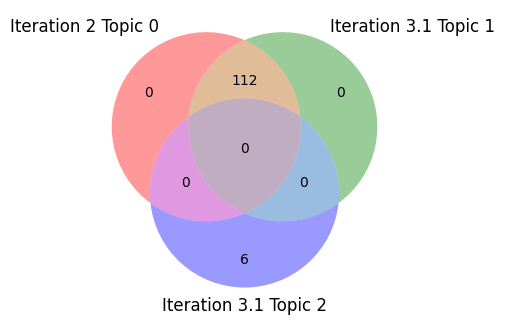

In [60]:
display(Markdown('**Comparing iteration 2 and 3 regarding topic 0**'))
plot_venn([topic_0_it_2_df['Abstract'], topic_1_it_3_1_df['Abstract'], topic_2_it_3_1_df['Abstract']], ["Iteration 2 Topic 0", "Iteration 3.1 Topic 1", "Iteration 3.1 Topic 2"])


Due to the changes of iteration 3.1 (min_cluster_size and n_components), the documents only in topic 1 of iteration 3 `performance_energy_power` (compared to topic 0 of iteration 2: `performance_multicore_memory`) moved to its own topic 2 `bloom_security_filter` in iteration 3.1.

#### Exclusion
In order to reduce the amount of papers we decied to validate papers from topic 2 `bloom_security_filter`:


In [61]:
it_03_01[it_03_01["BERTopic_Topic"] == 2]

,index,Title,DOI,Source,Year,Source title,Cited by,Document Type,Abstract,Author full names,...,BERTopic_Topic_Label,BERTopic_Probability,BERTopic_Count,BERTopic_Name,BERTopic_Representation,BERTopic_main,BERTopic_openai,BERTopic_aspect1,BERTopic_aspect2,BERTopic_Representative_Docs
13,14,A Highly-efficient Lattice-based Post-Quantum ...,10.46586/tches.v2024.i2.130-153,Scopus,2024,IACR Transactions on Cryptographic Hardware an...,17.0,Article,"Lattice-Based Cryptography (LBC) schemes, like...","Song, Ruibing; Cheung, Ray C.C.; Chen, Dong...",...,bloom_security_filter,1.0,7,2_bloom_security_filter_bloom filter,"['bloom', 'security', 'filter', 'bloom filter'...","['performance power', 'bandwidth', 'embedded s...",Power-efficient Security Architectures for Mob...,"['security', 'filter', 'offloading', 'power', ...","['performance power', 'bandwidth', 'mobile app...",['A Bloom filter is a simple space-efficient r...
75,80,Blockchain-based Decentralised Management of D...,10.14569/IJACSA.2024.01506144,Scopus,2024,International Journal of Advanced Computer Sci...,3.0,Article,With the recent impact of viral infections and...,"Alreshidi, Abdulrahman",...,bloom_security_filter,1.0,7,2_bloom_security_filter_bloom filter,"['bloom', 'security', 'filter', 'bloom filter'...","['performance power', 'bandwidth', 'embedded s...",Power-efficient Security Architectures for Mob...,"['security', 'filter', 'offloading', 'power', ...","['performance power', 'bandwidth', 'mobile app...",['A Bloom filter is a simple space-efficient r...
82,90,Compactrio based real time implementation of A...,10.4018/IJERTCS.2019040102,ACM Digital Library,2019,International Journal of Embedded and Real-Tim...,7.0,article,"For real-time embedded applications, several f...","Samir, El Adib; Naoufal, Raissouni; Raissoun...",...,bloom_security_filter,1.0,7,2_bloom_security_filter_bloom filter,"['bloom', 'security', 'filter', 'bloom filter'...","['performance power', 'bandwidth', 'embedded s...",Power-efficient Security Architectures for Mob...,"['security', 'filter', 'offloading', 'power', ...","['performance power', 'bandwidth', 'mobile app...",['A Bloom filter is a simple space-efficient r...
122,136,Efficient Software Architecture for IPSec Acce...,10.1109/DATE.2008.4484833,IEEE,2008,"2008 Design, Automation and Test in Europe",1.0,IEEE Conferences,Cryptographic accelerators and security proces...,A. Raghunathan; S. T. Chakradhar; J. Thoguluva,...,bloom_security_filter,1.0,7,2_bloom_security_filter_bloom filter,"['bloom', 'security', 'filter', 'bloom filter'...","['performance power', 'bandwidth', 'embedded s...",Power-efficient Security Architectures for Mob...,"['security', 'filter', 'offloading', 'power', ...","['performance power', 'bandwidth', 'mobile app...",['A Bloom filter is a simple space-efficient r...
124,138,Efficient software architecture for IPSec acce...,10.1145/1403375.1403656,ACM Digital Library,2008,"Proceedings of the Conference on Design, Autom...",NaN,inproceedings,Cryptographic accelerators and security proces...,"Chakradhar, Srimat T.; Raghunathan, Anand; T...",...,bloom_security_filter,1.0,7,2_bloom_security_filter_bloom filter,"['bloom', 'security', 'filter', 'bloom filter'...","['performance power', 'bandwidth', 'embedded s...",Power-efficient Security Architectures for Mob...,"['security', 'filter', 'offloading', 'power', ...","['performance power', 'bandwidth', 'mobile app...",['A Bloom filter is a simple space-efficient r...
223,242,K-stage pipelined bloom filter for packet clas...,10.1109/CSE.2009.408,Scopus,2009,NaN,7.0,Conference paper,A Bloom filter is a simple space-efficient ran...,"Wong, Stephan; Ahmadi, Mahmood",...,bloom_security_filter,1.0,7,2_bloom_security_filter_bloom filter,"['bloom', 'security', 'filter', 'bloom filter'...","['performance power', 'bandwidth', 'embedded s...",Power-efficient Security Architectures for Mob...,"['security', 'filter', 'offloading', 'power', ...","['performance power', 'bandwidth', 'mobile app...",



##### Remove

#### Remove
| Index | Title                                                                                                     | Reason                                |
|-------|-----------------------------------------------------------------------------------------------------------|---------------------------------------|
| 14    | A Highly-efficient Lattice-based Post-Quantum Cryptography Processor for IoT Applications                 | Not satisfying any inclusion criteria |
| 80    | Blockchain-based Decentralised Management of Digital Passports of Health (DPoH) for Vaccination Records   | Not satisfying any inclusion criteria |
| 90    | Compactrio based real time implementation of AES algorithm for embedded applications                      | Not satisfying any inclusion criteria |
| 136   | Efficient Software Architecture for IPSec Acceleration Using a Programmable Security Processor            | Not satisfying any $i_2$              |
| 138   | Efficient software architecture for IPSec acceleration using a programmable security processor            | Not satisfying any $i_2$              |
| 242   | K-stage pipelined bloom filter for packet classification                                                  | Not satisfying any inclusion criteria |


   
##### Keep

| Index | Title                                                                                                                 | Reason                                                              |
|-------|-----------------------------------------------------------------------------------------------------------------------|---------------------------------------------------------------------|
| 301   | Power consumption aware software architecture for M-health applications with adaptive security of network   protocols | Tackles energy/power efficiency/awareenes and software architecture |


## Iteration 4

Again we face a small amount of topics. In order to increase the number of topics we have to reduce the minimum cluster size.
```
min_cluster_size: 7 -> 6
``` 

### Iteration 4.0

In the following the topics from the findings of the larger parameter (`min_cluster_size: 7`) are shown.

In [62]:
it_04 = pd.read_csv("../output/02-BERTopic/bertopic_4.csv", converters={'Local File': str}, index_col=0)
it_04_statistcs = show_topic_statistics(it_04)

,,,count
BERTopic_Topic,BERTopic_Topic_Label,BERTopic_openai,
0,energy_software_consumption,Energy Efficiency in Software Development and Consumption,247
1,performance_energy_power,Energy-Efficient Performance Optimization in Multicore Architectures,112



<figure style="width: 600px">
    <img src="../output/02-BERTopic/4/topic_distribution.png" alt="Topic Distribution">
    <figcaption>Distribution of the afore mentioned topics</figcaption>
</figure>


#### Comparison to previous iteration
We are going to compare the topic `performance_energy_power` with the previous equivalent topic.



**Comparing iteration 2 and 3 regarding topic 0**

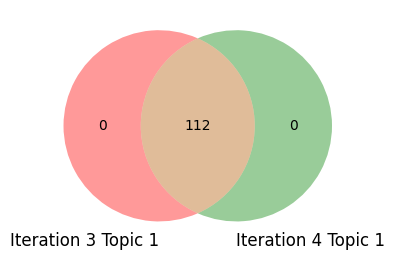

In [63]:
topic_1_it_4_df = it_04[it_04["BERTopic_Topic"] == 1]

display(Markdown('**Comparing iteration 2 and 3 regarding topic 0**'))
plot_venn([topic_1_it_3_1_df['Abstract'], topic_1_it_4_df['Abstract']], ["Iteration 3 Topic 1", "Iteration 4 Topic 1"])

The topic `performance_energy_power` is equivalent in both iterations. Therefore we need to get a more fine grained topic list.


### Iteration 4.1

In order to get more topics we are going to reduce the `min_cluster_size` (6 -> 5 -> 4).
We had to bring the `min_cluster_size` down to 4 in order to achieve a wider spread of topics.

After changing the parameters, more clusters could be identified as shown below:

In [64]:
it_04_01 = pd.read_csv("../output/02-BERTopic/bertopic_4.1.csv", converters={'Local File': str}, index_col=0)
it_04_01_statistcs = show_topic_statistics(it_04_01)


,,,count
BERTopic_Topic,BERTopic_Topic_Label,BERTopic_openai,
-1,Outlier,Energy-Efficient Architectures for Floating-Point and Fixed-Point Arithmetic in High-Performance Computing,27
0,software_energy_consumption,Energy Efficiency in Software Development and Design,247
1,parallel_scheduling_task,Energy-Efficient Scheduling for Heterogeneous Multicore Architectures in Parallel Computing,23
2,chip_topology_architectures,Multicore Architecture Optimization and Energy Efficiency in On-Chip Networks,13
3,memory_check_hardware,Energy-Efficient Memory Management Techniques in Mobile Computing,11
4,deep_neural_networks,Deep Learning Architectures and Their Efficiency in Real-Time Applications,7
5,memory_mapping_multicore,Multicore Architecture Optimization through Memory Management and Thread Mapping,7
6,cache_locking_multicore,Cache Resource Management in Multicore Processors,6
7,times_hardware_design,Hardware Optimization and Mixed Precision Methodologies for Efficient Computation in Heterogeneous Systems,5




<div style="display: flex; flex-direction: row; max-width: 100%; align-items: flex-end;">
    <figure style="flex: 1 1 auto; width: 50%;">
        <img src="../output/02-BERTopic/4.1/topic_distribution.png" alt="Topic Distribution">
        <figcaption>Distribution of the afore mentioned topics</figcaption>
    </figure>
    
<figure style="flex: 1 1 auto; width: 50%;">
    <img src="../output/02-BERTopic/4.1/visualize_documents.png" />
    <figcaption>Visualisation of the topics</figcaption>
</figure>
</div>

The right figure visualises the word vectors of the documents with the corresponding topics. The previously defined large topic `performance_energy_power` (1) from Iteration 4(.0) has been separated into further topics.

#### Comparison of Topics
The topic 0 from iteration 4 and topic 0 from iteration 4.1 seems to be the same again. While the topic 1 of iteration 4 disolved into further smaller topics. As shown in the following the analysis:

**Comparing iteration 3.1, 4 and 4.1**

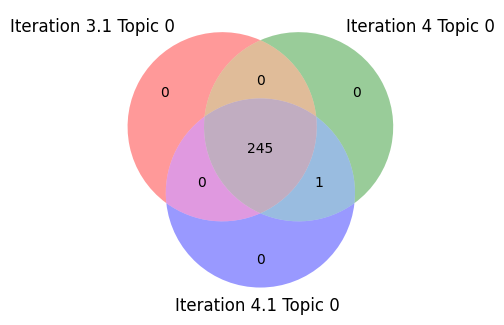

**Comparing iteration 3 and 4 regarding topic 0**

There are 246 in series Iteration 3 Topic 1, and 247 in series Iteration 4.1 Topic 0
0 Titles only in Iteration 3 Topic 1 but not in Iteration 4.1 Topic 0:
1 Titles only in Iteration 4.1 Topic 0 but not Iteration 3 Topic 1:


Index([186], dtype='int64')

,level_0,index,Title,DOI,Source,Year,Source title,Cited by,Document Type,Abstract,...,BERTopic_Topic_Label,BERTopic_Probability,BERTopic_Count,BERTopic_Name,BERTopic_Representation,BERTopic_main,BERTopic_openai,BERTopic_aspect1,BERTopic_aspect2,BERTopic_Representative_Docs
186,271,301,Power consumption aware software architecture ...,10.1109/TELSKS.2015.7357791,IEEE,2015,2015 12th International Conference on Telecomm...,0.0,IEEE Conferences,The goal of this paper is development of softw...,...,software_energy_consumption,0.666236,247,0_software_energy_consumption_energy consumption,"['software', 'energy', 'consumption', 'energy ...","['software energy', 'energy consumption', 'pow...",Energy Efficiency in Software Development and ...,"['software', 'energy', 'consumption', 'design'...","['software energy', 'power consumption', 'sust...",['The prevalence of mobile computing platforms...


In [65]:
topic_1_it_4_df = it_04[it_04["BERTopic_Topic"] == 0].reset_index()
topic_1_it_4_1_df = it_04_01[it_04_01["BERTopic_Topic"] == 0].reset_index()

display(Markdown('**Comparing iteration 3.1, 4 and 4.1**'))
plot_venn([topic_0_it_3_1_df["Abstract"], topic_1_it_4_df["Abstract"], topic_1_it_4_1_df["Abstract"]],
          ["Iteration 3.1 Topic 0", "Iteration 4 Topic 0", "Iteration 4.1 Topic 0 "])

display(Markdown('**Comparing iteration 3 and 4 regarding topic 0**'))
only_t0_it_3_1, only_t0_it_4_1 = compare_data_frames(topic_0_it_3_1_df, topic_1_it_4_1_df, "Iteration 3 Topic 1", "Iteration 4.1 Topic 0")

The topic seem to be almost identically with small differences. Throughout the iterations 4 and 4.1 the topic did not change. 

#### Exclusion
In order to reduce the amount of papers, we are going to check all topcis with n <=10:


In [66]:
it_04_01[it_04_01['BERTopic_Topic'] == 10]


agg = it_04_01.groupby(["BERTopic_Topic", "BERTopic_Topic_Label", "BERTopic_openai"]).agg(count=("Abstract", "count"))
#display(agg.filter(lambda x: x['count'] <= 10))
#display(agg[agg['count'] <= 10])
it_04_01_exclusion_table_template_data = {
    "topic": [],
    "index": [],
    "title": [],
    "reason": [],
    "result": []
}
for row in agg[agg['count'] <= 10].itertuples():
    topic, label, openai = row.Index
    display(Markdown(f"**(Topic {topic} - {label}): {openai} with {row.count} documents**"))
    for row in it_04_01[it_04_01['BERTopic_Topic'] == topic][['index', 'Title', 'BERTopic_Topic']].itertuples():
        #print(f"\t {row.index}\t{row.Title}")
        it_04_01_exclusion_table_template_data['topic'].append(row.BERTopic_Topic)
        it_04_01_exclusion_table_template_data['index'].append(row.index)
        it_04_01_exclusion_table_template_data['title'].append(row.Title)
        it_04_01_exclusion_table_template_data['reason'].append("")
        it_04_01_exclusion_table_template_data['result'].append("")

pd.DataFrame(it_04_01_exclusion_table_template_data).to_markdown('../output/02-BERTopic/4.1/exclusion_table.md', index=False)
display(Markdown("\n\n**The table has been generated to 4.1/exclusion_table.md and is going to be filled in the next cell. Here are the indices of these documents:**"))
print(f"{len(it_04_01_exclusion_table_template_data['index'])}:", it_04_01_exclusion_table_template_data['index'])
#print(type(agg))

**(Topic 4 - deep_neural_networks): Deep Learning Architectures and Their Efficiency in Real-Time Applications with 7 documents**

**(Topic 5 - memory_mapping_multicore): Multicore Architecture Optimization through Memory Management and Thread Mapping with 7 documents**

**(Topic 6 - cache_locking_multicore): Cache Resource Management in Multicore Processors with 6 documents**

**(Topic 7 - times_hardware_design): Hardware Optimization and Mixed Precision Methodologies for Efficient Computation in Heterogeneous Systems with 5 documents**

**(Topic 8 - memory_performance_multicore): Multicore Architectures and Transactional Memory in Concurrent Programming with 5 documents**

**(Topic 9 - loop_overhead_frequency): Energy Efficiency and Performance Optimization in Multicore Architectures with 4 documents**

**(Topic 10 - dynamic voltage_voltage_scaling): Dynamic Voltage Scaling and Power Management Techniques with 4 documents**



**The table has been generated to 4.1/exclusion_table.md and is going to be filled in the next cell. Here are the indices of these documents:**

38: [18, 46, 63, 193, 250, 293, 338, 21, 211, 248, 294, 317, 325, 355, 41, 55, 68, 129, 300, 333, 27, 59, 123, 206, 393, 65, 67, 156, 280, 371, 35, 165, 220, 269, 95, 96, 283, 316]


| topic | index | title                                                                                                                                |                reason                 | result  |
| ----: | ----: | :----------------------------------------------------------------------------------------------------------------------------------- | :-----------------------------------: | :------ |
|     4 |    18 | A Survey: Collaborative Hardware and Software Design in the Era of Large Language Models                                             |         Not satisfying $i_1$          | Exclude |
|     4 |    46 | An Edge 3D CNN Accelerator for Low-Power Activity Recognition                                                                        |         Not satisfying $i_1$          | Exclude |
|     4 |    63 | Analyzing and Comparing Deep Learning Models on an ARM 32 Bits Microcontroller for Pre-Impact Fall Detection                         |         Not satisfying $i_1$          | Exclude |
|     4 |   193 | GINA: Exploiting Graph Neural Network Layer Features for Energy Efficient Inferencing in NVM-based PIM Accelerators                  |         Not satisfying $i_1$          | Exclude |
|     4 |   250 | Low-power and high-speed deep FPGA inference engines for weed classification at the edge                                             |         Not satisfying $i_1$          | Exclude |
|     4 |   293 | Performance and energy characterization of high-performance low-cost cornerness detection on GPUs and multicores                     |         Not satisfying $i_1$          | Exclude |
|     4 |   338 | Socrates-D 2.0: A Low Power High Throughput Architecture for Deep Network Training                                                   |         Not satisfying $i_1$          | Exclude |
|     5 |    21 | A comprehensive study of task coalescing for selecting parallelism granularity in a two-stage bidiagonal reduction                   |         Not satisfying $i_1$          | Exclude |
|     5 |   211 | Impact of level-2 cache sharing on the performance and power requirements of homogeneous multicore embedded systems                  |         Not satisfying $i_1$          | Exclude |
|     5 |   248 | Locality and balance for communication-aware thread mapping in multicore systems                                                     |         Not satisfying $i_1$          | Exclude |
|     5 |   294 | Performance and power comparisons of MPI Vs Pthread implementations on multicore systems                                             |         Not satisfying $i_1$          | Exclude |
|     5 |   317 | Region based cache coherence for tiled MPSoCs                                                                                        | Not satisfying an inclusion criteria  | Exclude |
|     5 |   325 | Runtime-Guided Management of Scratchpad Memories in Multicore Architectures                                                          | Not satisfying an inclusion criteria  | Exclude |
|     5 |   355 | Studying OpenMP thread mapping for parallel linear algebra kernels on multicore system                                               | Not satisfying an inclusion criteria  | Exclude |
|     6 |    41 | Adaptive power optimization of on-chip SNUCA cache on tiled chip multicore architecture using remap policy                           |         Not satisfying $i_1$          | Exclude |
|     6 |    55 | An effective measurement technique of level-2 cache performance for multicore embedded systems                                       | Not satisfying an inclusion criteria  | Exclude |
|     6 |    68 | ArC: DVFS-aware asymmetric-retention STT-RAM caches for energy-efficient multicore processors                                        |         Not satisfying $i_1$          | Exclude |
|     6 |   129 | Dynamic cache pooling in 3D multicore processors                                                                                     | Not satisfying an in clusion criteria | Exclude |
|     6 |   300 | Power and performance analysis of multimedia applications running on low-power devices by cache modeling                             |         Not satisfying $i_1$          | Exclude |
|     6 |   333 | Simulation of level-2 cache locking in multicore parallel computing systems                                                          | Not satisfying an inclusion criteria  | Exclude |
|     7 |    27 | A mixed precision Monte Carlo methodology for reconfigurable accelerator systems                                                     | Not satisfying an inclusion criteria  | Exclude |
|     7 |    59 | Analysis and modeling of collaborative execution strategies for heterogeneous CPU-FPGA architectures                                 | Not satisfying an inclusion criteria  | Exclude |
|     7 |   123 | Development of scientific software for HPC architectures using open ACC: The case of LQCD                                            | Not satisfying an inclusion criteria  | Exclude |
|     7 |   206 | HASCO: towards agile &lt;u&gt;ha&lt;/u&gt;rdware and &lt;u&gt;s&lt;/u&gt;oftware &lt;u&gt;co&lt;/u&gt;-design for tensor computation |         Not satisfying $i_2$          | Exclude |
|     7 |   393 | ViA: A Novel Vision-Transformer Accelerator Based on FPGA                                                                            | Not satisfying an inclusion criteria  | Exclude |
|     8 |    65 | Analyzing the energy efficiency of the memory subsystem in multicore processors                                                      |         Not satisfying $i_1$          | Exclude |
|     8 |    67 | Application performance on the Blue Gene architecture                                                                                |         Not satisfying $i_2$          | Exclude |
|     8 |   280 | On the energy and performance of commodity hardware transactional memory                                                             | Not satisfying an inclusion criteria  | Exclude |
|     8 |   371 | The impact of multicore on math software                                                                                             |         Not satisfying $i_2$          | Exclude |
|     9 |    35 | AVX overhead profiling: How much does your fast code slow you down?                                                                  |         Not satisfying $i_2$          | Exclude |
|     9 |   165 | Energy footprint of advanced dense numerical linear algebra using tile algorithms on multicore architectures                         |         Not satisfying $i_1$          | Exclude |
|     9 |   220 | Influence of loop transformations on performance and energy consumption of the multithreded WZ factorization                         |         Not satisfying $i_1$          | Exclude |
|     9 |   269 | Modeling the Power Variability of Core Speed Scaling on Homogeneous Multicore Systems                                                |         Not satisfying $i_1$          | Exclude |
|    10 |    95 | Compile-time dynamic voltage scaling settings: Opportunities and limits                                                              | Not satisfying an inclusion criteria  | Exclude |
|    10 |    96 | Compile-time dynamic voltage scaling settings: opportunities and limits                                                              | Not satisfying an inclusion criteria  | Exclude |
|    10 |   283 | Optimal energy saving DVFS approach of embedded processors                                                                           |         Not satisfying $i_1$          | Exclude |
|    10 |   316 | Reducing Jitter in Embedded Systems Employing a Time-Triggered Software Architecture and Dynamic Voltage Scaling                     |         Not satisfying $i_1$          | Exclude |
|     8 |   156 | Energy consumption on software transactional memories                                                                                |  Satisfying both inclusion criteria   | Keep    |

## Iteration 5
With the list containing 322 documents and the settings of the previous iteration 4.1, the amount of topics became 22. 


In [67]:
it_05 = pd.read_csv("../output/02-BERTopic/bertopic_5.csv", converters={'Local File': str}, index_col=0)
it_05_statistcs = show_topic_statistics(it_05)

,,,count
BERTopic_Topic,BERTopic_Topic_Label,BERTopic_openai,
-1,Outlier,Energy Efficiency in Software Development and Consumption,78
0,green_software_sustainability,Green Software Engineering and Sustainability Practices,31
1,multicore_task_parallel,Multicore Task Scheduling for Energy-Efficient Parallel Computing,30
2,data_sensor_control,Smart Energy Monitoring and Control Systems in Buildings,22
3,memory_point_check,Energy-Aware Computing and Fixed-Point Arithmetic in Mobile and Wireless Systems,17
4,energy_software_energy consumption,Energy Efficiency in Software Architectures: Monolithic vs Microservices,17
5,green_computing_carbon,Green Computing and Energy Efficiency in Cloud Environments,15
6,power_models_power consumption,Automated Power Modeling and Optimization in Embedded Systems,12
7,chip_topology_router,Network-on-Chip Architectures for Enhanced Performance and Power Efficiency in Multicore Processors,10


<div style="display: flex; flex-direction: row; max-width: 100%; align-items: flex-end;">
    <figure style="flex: 1 1 auto; width: 50%;">
        <img src="../output/02-BERTopic/5/topic_distribution.png" alt="Topic Distribution">
        <figcaption>Distribution of the afore mentioned topics</figcaption>
    </figure>
    
<figure style="flex: 1 1 auto; width: 50%;">
    <img src="../output/02-BERTopic/5/visualize_documents.png" />
    <figcaption>Visualisation of the topics</figcaption>
</figure>
</div>


Some topics seem to be equivalent and we therefore doing another sub iteration

### Iteration 5.1
In order to reduce the amount of topics, the parameters require some adjustments. 
Changing the cluster size to 10 reduces the number of topic down to 9 topics.

In [68]:
it_05_01 = pd.read_csv("../output/02-BERTopic/bertopic_5.1.csv", converters={'Local File': str}, index_col=0)
it_05_01_statistics = show_topic_statistics(it_05_01)

,,,count
BERTopic_Topic,BERTopic_Topic_Label,BERTopic_openai,
-1,Outlier,Energy Efficiency in Software Architecture and AI Systems,68
0,energy_mobile_consumption,Energy-Aware Software Design and Power Consumption Optimization in Embedded and Mobile Systems,60
1,green_software_sustainability,Green Software Engineering and Sustainability Practices,31
2,multicore_performance_task,Energy-efficient Task Scheduling in Heterogeneous Multicore Architectures,30
3,energy_software_energy consumption,Energy Efficiency in Software Development and Application,30
4,patterns_design patterns_design,Energy Impact of Design Patterns in Software Development,24
5,data_power_sensor,Smart Energy Monitoring and Management Systems,22
6,memory_point_check,Energy-Aware Software Design for Mobile Computing and Fixed-Point Arithmetic Implementation,17
7,green_computing_carbon,Green Computing and Energy Efficiency in Cloud and Embedded Systems,15


<div style="display: flex; flex-direction: row; max-width: 100%; align-items: flex-end;">
    <figure style="flex: 1 1 auto; width: 50%;">
        <img src="../output/02-BERTopic/5.1/topic_distribution.png" alt="Topic Distribution">
        <figcaption>Distribution of the afore mentioned topics</figcaption>
    </figure>
    
<figure style="flex: 1 1 auto; width: 50%;">
    <img src="../output/02-BERTopic/5.1/visualize_documents.png" />
    <figcaption>Visualisation of the topics</figcaption>
</figure>
</div>

The sizes of the topics grew by reducing the amount of topics and aren't (compared to previous iterations) all moved to one big topic.

The most promising topics for further document reduction are:
- Energy-efficient Task Scheduling in Heterogeneous Multicore Architectures (Topic 2; 30 Topics)
- Energy-Efficient Design and Synthesis of Embedded Systems (Topic 8; 15 Documents)
- Network-on-Chip Architectures for Power-Efficient Multicore Systems (Topic 9; 10 Documents)

In [69]:


it_05_01_exclusion_table_template_data = {
    "topic": [],
    "index": [],
    "title": [],
    "reason": [],
    "result": []
}
for row in it_05_01[it_05_01['BERTopic_Topic'].isin([2,8,9])][['index', 'Title', 'BERTopic_Topic']].itertuples():
    it_05_01_exclusion_table_template_data['topic'].append(row.BERTopic_Topic)
    it_05_01_exclusion_table_template_data['index'].append(row.index)
    it_05_01_exclusion_table_template_data['title'].append(row.Title)
    it_05_01_exclusion_table_template_data['reason'].append("")
    it_05_01_exclusion_table_template_data['result'].append("")

pd.DataFrame(it_05_01_exclusion_table_template_data).to_markdown('../output/02-BERTopic/5.1/exclusion_table.md', index=False)
display(Markdown("\n\n**The table has been generated to 5.1/exclusion_table.md and is going to be filled in the next cell. Here are the indices of these documents:**"))
print(f"{len(it_05_01_exclusion_table_template_data['index'])}:", it_05_01_exclusion_table_template_data['index'])



**The table has been generated to 5.1/exclusion_table.md and is going to be filled in the next cell. Here are the indices of these documents:**

55: [5, 13, 19, 61, 62, 82, 97, 99, 100, 101, 109, 112, 119, 131, 139, 151, 159, 168, 172, 173, 176, 177, 179, 185, 191, 210, 212, 214, 217, 231, 232, 239, 244, 257, 261, 262, 272, 274, 277, 285, 292, 297, 326, 327, 329, 330, 335, 345, 361, 362, 366, 368, 372, 378, 388]


|   topic |   index | title                                                                                                                                      | reason                                 | result  |
|--------:|--------:|:-------------------------------------------------------------------------------------------------------------------------------------------|:---------------------------------------|:--------|
|       2 |       5 | A Cache Contention-aware Run-time Scheduling for Power-constrained Asymmetric Multicore Processors                                         | Not satisfying $i_1$                   | Exclude |
|       8 |      19 | A comparative analysis of self-adaptive patterns in cyber-physical systems                                                                 | Not satisfying $i_2$                   | Exclude |
|       2 |      61 | Analysis of parallel algorithms for energy conservation in scalable multicore architectures                                                | Not satisfying $i_1$                   | Exclude |
|       9 |      62 | Analyzing Binary Tree based Topology Configuration for Energy Efficient Multicore Architectures                                            | Not satisfying $i_1$                   | Exclude |
|       9 |      82 | Broadcast-Enabled Massive Multicore Architectures: A Wireless RF Approach                                                                  | Not satisfying any inclusion criteria  | Exclude |
|       8 |      97 | Component-Based Real-Time Operating System for Embedded Applications                                                                       | Not satisfying any inclusion criteria  | Exclude |
|       8 |      99 | Computer Systems for Autonomous Vehicles                                                                                                   | Not satisfying any inclusion criteria  | Exclude |
|       8 |     100 | Computer systems for autonomous vehicles                                                                                                   | Not satisfying any inclusion criteria  | Exclude |
|       9 |     101 | Computing and design for software and silicon manufacturing                                                                                | Not satisfying any inclusion criteria  | Exclude |
|       9 |     109 | Design an energy-efficient wireless routers with Dbm noc architecture to minimize the communication latency                                | Not satisfying $i_1$                   | Exclude |
|       8 |     112 | Design and field testing of a rover with an actively articulated suspension system in a Mars analog terrain                                | Not satisfying any inclusion criteria  | Exclude |
|       2 |     119 | Design space exploration of many-core processors for a high-performance guitar synthesizer                                                 | Not satisfying any inclusion criteria  | Exclude |
|       2 |     131 | Dynamic voltage and frequency scaling optimization for multicore architectures                                                             | Not satisfying $i_1$                   | Exclude |
|       8 |     139 | Embedded software development in research environment: A practical guide for non-experts                                                   | Not satisfying any inclusion criteria  | Exclude |
|       8 |     151 | Energy Efficiency of ROS Nodes in Different Languages: Publisher-Subscriber Case Studies                                                   | Not satisfying any inclusion criteria  | Exclude |
|       2 |     159 | Energy driven adaptivity in stream parallel computations                                                                                   | Not satisfying $i_1$                   | Exclude |
|       2 |     168 | Energy-Efficient Cache-Aware Scheduling on Heterogeneous Multicore Systems                                                                 | Not satisfying $i_1$                   | Exclude |
|       2 |     172 | Energy-efficient virtual machine scheduling in performance-asymmetric multi-core architectures                                             | Not satisfying $i_1$                   | Exclude |
|       8 |     173 | Enhanced software development process for CubeSats to cope with space radiation faults                                                     | Not satisfying any inclusion criteria  | Exclude |
|       9 |     176 | Evaluating effects of thermal management in wireless NoC-enabled multicore architectures                                                   | Not satisfying any inclusion criteria  | Exclude |
|       2 |     177 | Evaluating scientific workflow execution on an asymmetric multicore processor                                                              | Not satisfying any inclusion criteria  | Exclude |
|       2 |     179 | Evaluating the Performance of Various MOEA's to Optimize Scheduling Overhead in Homogeneous Multicore Architecture                         | Not satisfying any inclusion criteria  | Exclude |
|       9 |     185 | Folded torus based power aware interconnection topology for high-performance multicore architecture                                        | Not satisfying any inclusion criteria  | Exclude |
|       2 |     191 | GA-EDA: Hybrid Design Space Exploration Engine for Multicore Architecture                                                                  | Not satisfying any inclusion criteria  | Exclude |
|       2 |     210 | Impact of Processor Frequency Scaling on Performance and Energy Consumption for WZ Factorization on Multicore Architecture                 | Not satisfying any inclusion criteria  | Exclude |
|       9 |     212 | Impact of non-uniform subnets on the performance of wireless network-on-chip architectures                                                 | Not satisfying any inclusion criteria  | Exclude |
|       8 |     214 | Implementation of a nanosatellite attitude determination and control system for the T-Sat1 mission                                         | Not satisfying any inclusion criteria  | Exclude |
|       2 |     217 | Improving energy efficiency by phase-grained migration for asymmetric multicore                                                            | Not satisfying any inclusion criteria  | Exclude |
|       2 |     231 | Investigating different general-purpose and embedded multicores to achieve optimal trade-offs between performance and energy               | Not satisfying any inclusion criteria  | Exclude |
|       8 |     232 | Investigating software deployment on heterogeneous platforms                                                                               | Not satisfying any inclusion criteria  | Exclude |
|       8 |     239 | Issues in synthesis of board-level systems                                                                                                 | Not satisfying any inclusion criteria  | Exclude |
|       9 |     244 | Latency-Aware Frequency Scaling in Time-Triggered Network-on-Chip Architecture                                                             | Not satisfying any inclusion criteria  | Exclude |
|       9 |     257 | Microcode compression using structured-constrained clustering                                                                              | Not satisfying any inclusion criteria  | Exclude |
|       8 |     261 | Mining the ROS ecosystem for green architectural tactics in robotics and an empirical evaluation                                           | Not satisfying any inclusion criteria  | Exclude |
|       9 |     262 | MoDe-X: Microarchitecture of a layout-aware modular decoupled crossbar for on-chip interconnects                                           | Not satisfying any inclusion criteria  | Exclude |
|       2 |     272 | NSGA-II-based design space exploration for energy and throughput aware multicore architectures                                             | Not satisfying any inclusion criteria  | Exclude |
|       2 |     274 | Near-optimal energy-efficient partial-duplication task mapping of real-time parallel applications                                          | Not satisfying any inclusion criteria  | Exclude |
|       2 |     277 | On energy conservation in data centers                                                                                                     | Not satisfying any inclusion criteria  | Exclude |
|       2 |     285 | Optimisation problems for dynamic concurrent task-based systems                                                                            | Not satisfying any inclusion criteria  | Exclude |
|       2 |     292 | Parallel performance and energy efficiency of modern video encoders on multithreaded architectures                                         | Not satisfying any inclusion criteria  | Exclude |
|       8 |     297 | Platform-based design and software design methodology for embedded systems                                                                 | Not satisfying $i_2$                   | Exclude |
|       2 |     326 | SEAL: Soft error aware low power scheduling by Monte Carlo state space under the influence of stochastic spatial and temporal dependencies | Not satisfying any inclusion criteria  | Exclude |
|       2 |     327 | SEDEA: A Sensible Approach to Account DRAM Energy in Multicore Systems                                                                     | Not satisfying any inclusion criteria  | Exclude |
|       2 |     329 | STEER: Asymmetry-aware Energy Efficient Task Scheduler for Cluster-based Multicore Architectures                                           | Not satisfying any inclusion criteria  | Exclude |
|       2 |     330 | Selective High-Latency Arithmetic Instruction Reuse in Multicore Processors                                                                | Not satisfying any inclusion criteria  | Exclude |
|       2 |     335 | Simultaneous Scheduling and Core-Type Optimization for Moldable Fork-Join Tasks on Heterogeneous Multicores                                | Not satisfying any inclusion criteria  | Exclude |
|       8 |     361 | System architecture and software design for Electric Vehicles                                                                              | Not satisfying any inclusion criteria  | Exclude |
|       2 |     362 | Task scheduling using Ant Colony Optimization in multicore architectures: a survey                                                         | Not satisfying any inclusion criteria  | Exclude |
|       2 |     366 | The analysis of impact of energy efficiency requirements on programming environments                                                       | Not satisfying any inclusion criteria  | Exclude |
|       2 |     368 | The design and implementation of heterogeneous multicore systems for energy-efficient speculative thread execution                         | Not satisfying any inclusion criteria  | Exclude |
|       2 |     372 | The impact of parallel programming interfaces on energy                                                                                    | Not satisfying any inclusion criteria  | Exclude |
|       2 |     378 | To extend battery life, use two processors (Not One)                                                                                       | Not satisfying any inclusion criteria  | Exclude |
|       2 |     388 | Trade-off between performance, fault tolerance and energy consumption in duplication-based taskgraph scheduling                            | Not satisfying any inclusion criteria  | Exclude |
|       2 |      13 | A Green Perspective on Structured Parallel Programming                                                                                     | Not sure for now could fit             | Keep    |
|       8 |     345 | Software implementation strategies for power-conscious systems                                                                             | Satisfying both inclusion criteria     | Keep    |

## Iteration 6
Keeping the parameters of iteration 5.1, the reduced document list is now separated into 5 topics.

In [70]:
it_06 = pd.read_csv("../output/02-BERTopic/bertopic_6.csv", converters={'Local File': str}, index_col=0)
it_06_statistics = show_topic_statistics(it_06)


,,,count
BERTopic_Topic,BERTopic_Topic_Label,BERTopic_openai,
-1,Outlier,Energy-Efficient Software Architectures and Dynamic Optimization Approaches,54
0,energy_consumption_power,Energy Consumption Optimization in Mobile and Embedded Systems,92
1,green_software_sustainability,Green Software Engineering and Sustainability Practices,55
2,power_energy_data,Energy Management and Power Optimization in Smart Systems,30
3,energy_software_energy consumption,Energy Efficiency in Software Development and Consumption,20
4,patterns_design patterns_energy,Energy Efficiency of Design Patterns in Software Development,18


<div style="display: flex; flex-direction: row; max-width: 100%; align-items: flex-end;">
    <figure style="flex: 1 1 auto; width: 50%;">
        <img src="../output/02-BERTopic/6/topic_distribution.png" alt="Topic Distribution">
        <figcaption>Distribution of the afore mentioned topics</figcaption>
    </figure>
    
<figure style="flex: 1 1 auto; width: 50%;">
    <img src="../output/02-BERTopic/6/visualize_documents.png" />
    <figcaption>Visualisation of the topics</figcaption>
</figure>
</div>

For further reduction of the documents, we select topic 2 for exclusion check:

In [71]:

it_06_exclusion_table_template_data = {
    "topic": [],
    "index": [],
    "title": [],
    "reason": [],
    "result": []
}
for row in it_06[it_06['BERTopic_Topic'] == 2][['index', 'Title', 'BERTopic_Topic']].itertuples():

    it_06_exclusion_table_template_data['topic'].append(row.BERTopic_Topic)
    it_06_exclusion_table_template_data['index'].append(row.index)
    it_06_exclusion_table_template_data['title'].append(row.Title)
    it_06_exclusion_table_template_data['reason'].append("")
    it_06_exclusion_table_template_data['result'].append("")
pd.DataFrame(it_06_exclusion_table_template_data).to_markdown('../output/02-BERTopic/6/exclusion_table.md', index=False)
display(Markdown("\n\n**The table has been generated to 6/exclusion_table.md and is going to be filled in the next cell. Here are the indices of these documents:**"))
print(f"{len(it_06_exclusion_table_template_data['index'])}:", it_06_exclusion_table_template_data['index'])



**The table has been generated to 6/exclusion_table.md and is going to be filled in the next cell. Here are the indices of these documents:**

30: [16, 22, 49, 110, 114, 115, 117, 118, 124, 127, 140, 154, 158, 163, 192, 197, 207, 223, 236, 267, 282, 336, 337, 347, 348, 349, 352, 359, 375, 376]


| topic | index |                                                                   title                                                                    |                 reason                 | result  |
| ----: | ----: | :----------------------------------------------------------------------------------------------------------------------------------------: | :------------------------------------: | :-----: |
|     2 |    16 |                                      A Multi-Sensor-Based System for Cardiovascular Health Monitoring                                      | Not satisfying any inclusion criteria  | Exclude |
|     2 |    22 |                                           A dynamic power profiling of embedded computer systems                                           |          Not satisfying $i_1$          | Exclude |
|     2 |    49 |                              An Energy Information Gateway for use in residential and commercial environments                              | Not satisfying any inclusion criteria  | Exclude |
|     2 |   110 |                              Design and Implementation of Energy Consumption Data Collector for Tram Stations                              | Not satisfying any inclusion criteria  | Exclude |
|     2 |   114 |                        Design challenges of a low power ARM based image processing sub system for a portable radar                         | Not satisfying any inclusion criteria  | Exclude |
|     2 |   115 |                                      Design of Whole Chain Temperature Monitoring System for Raw Milk                                      | Not satisfying any inclusion criteria  | Exclude |
|     2 |   117 |                         Design of a microservices-based architecture for residential energy efficiency monitoring                          | Not satisfying any inclusion criteria  | Exclude |
|     2 |   118 |                                   Design of the Electrical Performance Test System for AC and DC Relays                                    | Not satisfying any inclusion criteria  | Exclude |
|     2 |   124 | Development of the reactive power compensation laboratory bench and its integration into the training simulator of dispatch control system | Not satisfying any inclusion criteria  | Exclude |
|     2 |   127 |                 Digitization of Centrifugal Compressor Asset as One of Key Elements of Overall Digitized Industrial Plant                  | Not satisfying any inclusion criteria  | Exclude |
|     2 |   140 |                                 Embedded transient shock signal storage test technique under high overload                                 | Not satisfying any inclusion criteria  | Exclude |
|     2 |   154 |                      Energy aware-Mobile-based architecture for maximizing energy savings during computer idle times                       |          Not satisfying $i_1$          | Exclude |
|     2 |   158 |                           Energy consumption prediction system for intelligent building based on fuzzy petri net                           | Not satisfying any inclusion criteria  | Exclude |
|     2 |   192 |                         GESE: Granular Electric Sub-Metering Economics in the Context of Automated Demand Response                         | Not satisfying any inclusion criteria  | Exclude |
|     2 |   197 |                                    Green Monitoring System for Energy Saving in Accommodation Services                                     | Not satisfying any inclusion criteria  | Exclude |
|     2 |   207 |                         Hardware and software architecture of a smart meter based on electrical signature analysis                         | Not satisfying any inclusion criteria  | Exclude |
|     2 |   223 |                        Innovative Circuit Designs for Achieving Ultra-Low Power Consumption in Wearable Electronics                        | Not satisfying any inclusion criteria  | Exclude |
|     2 |   236 |                          IoT Network of Sensor Array for Intrusion Detection and Diagnosis of Electrical Systems                           | Not satisfying any inclusion criteria  | Exclude |
|     2 |   267 |                                            Modeling of energy-sensitive manufacturing processes                                            | Not satisfying any inclusion criteria  | Exclude |
|     2 |   282 |                Optimal Design of Transformer Winding Thermostat Verification Device Based on Simulated Annealing Algorithm                 | Not satisfying any inclusion criteria  | Exclude |
|     2 |   336 |                                                    Smart environment monitoring testbed                                                    | Not satisfying any inclusion criteria  | Exclude |
|     2 |   337 |                                            Smoke sensor for intelligent power distribution room                                            | Not satisfying any inclusion criteria  | Exclude |
|     2 |   347 |                                          Software modeling for embedded and mobile sensor system                                           | Not satisfying any inclusion criteria  | Exclude |
|     2 |   349 |                            Software power optimization: analysis and optimization for energy-efficient software                            | Exclude, due to duplicate of above one | Exclude |
|     2 |   352 |                                      Strategies for increasing energy efficiency in electrical drives                                      | Not satisfying any inclusion criteria  | Exclude |
|     2 |   375 |                                       The research of home Intelligent power system based on ZigBee                                        | Not satisfying any inclusion criteria  | Exclude |
|     2 |   376 |                       The software design of energy efficiency data acquisition and management of operational ships                        | Not satisfying any inclusion criteria  | Exclude |
|     2 |   163 |                                              Energy efficient operating systems and software                                               |   Satisfying both inclusion criteria   |  Keep   |
|     2 |   348 |                            Software power optimization: Analysis and optimization for energy-efficient software                            |   Satisfying both inclusion criteria   |  Keep   |
|     2 |   359 |                                                        Sustainable Software Design                                                         |  Satisfying both inclusion criteria\*  |  Keep   |

\*:Checked the abstract since the title sounds promising to be sure it fits

## Topic 7
Applying the criteria of iteration 6, the documebtn list gets separated into 5 topics.

In [72]:
it_07 = pd.read_csv("../output/02-BERTopic/bertopic_7.csv", converters={'Local File': str}, index_col=0)
it_07_statistics = show_topic_statistics(it_07)

,,,count
BERTopic_Topic,BERTopic_Topic_Label,BERTopic_openai,
-1,Outlier,Energy-Aware Machine Learning Systems and Sustainability,17
0,energy_consumption_power,Energy Consumption Optimization in Mobile and Embedded Software Systems,100
1,software_energy_green,Sustainable Software Engineering and Energy Efficiency,93
2,energy_design patterns_patterns,Energy Efficiency in Software Design Patterns,17
3,energy_software_quality,Sustainable Software Architecture and Energy Efficiency Optimization,15


<div style="display: flex; flex-direction: row; max-width: 100%; align-items: flex-end;">
    <figure style="flex: 1 1 auto; width: 50%;">
        <img src="../output/02-BERTopic/7/topic_distribution.png" alt="Topic Distribution">
        <figcaption>Distribution of the afore mentioned topics</figcaption>
    </figure>
    
<figure style="flex: 1 1 auto; width: 50%;">
    <img src="../output/02-BERTopic/7/visualize_documents.png" />
    <figcaption>Visualisation of the topics</figcaption>
</figure>
</div>

The topics are not spread enough, and the majority is located in topic 0 and 1. In order to separate the topics more we are adjusting the parameters in sub-iteration 7.1.

### Iteration 7.1
We adjusted the parameter min_cluster_size from `10` down to `9`.

In [73]:
it_07_01 = pd.read_csv("../output/02-BERTopic/bertopic_7.1.csv", converters={'Local File': str}, index_col=0)
it_07_01_statistics = show_topic_statistics(it_07_01)

,,,count
BERTopic_Topic,BERTopic_Topic_Label,BERTopic_openai,
-1,Outlier,Energy-Efficient Architectures for Distributed Systems,32
0,software_green_energy,Sustainable Software Development and Green Computing Practices,93
1,memory_hardware_performance,Power-Efficient Hardware-Software Co-Design for Data-Dominated Systems,29
2,mobile_consumption_energy,Energy Efficiency in Mobile Application Design and Consumption Patterns,26
3,power_energy_consumption,Energy Optimization in Embedded Systems Software Design,19
4,design patterns_patterns_design,Energy Efficiency in Software Design Patterns,17
5,quality_energy_optimization,Sustainable Software Architecture and Energy Efficiency Optimization,15
6,energy_program_software,Energy-Aware Software Development for Heterogeneous Multicore Platforms,11


<div style="display: flex; flex-direction: row; max-width: 100%; align-items: flex-end;">
    <figure style="flex: 1 1 auto; width: 50%;">
        <img src="../output/02-BERTopic/7.1/topic_distribution.png" alt="Topic Distribution">
        <figcaption>Distribution of the afore mentioned topics</figcaption>
    </figure>
    
<figure style="flex: 1 1 auto; width: 50%;">
    <img src="../output/02-BERTopic/7.1/visualize_documents.png" />
    <figcaption>Visualisation of the topics</figcaption>
</figure>
</div>

Since the iterations 7 and 7.1 have a similar topic, we are investigating the differences between iteration 7 topic 1 and iteration 7.1 topic 0.

**Comparing iteration 7 and 7.1**

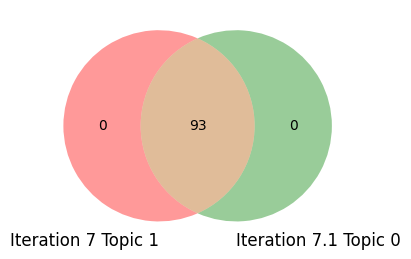

**Comparing iteration 3 and 4 regarding topic 0**

There are 93 in series Iteration 7 Topic 1, and 93 in series Iteration 7.1 Topic 0
0 Titles only in Iteration 7 Topic 1 but not in Iteration 7.1 Topic 0:
0 Titles only in Iteration 7.1 Topic 0 but not Iteration 7 Topic 1:


In [74]:
topic_1_it_7_df = it_07[it_07["BERTopic_Topic"] == 1].reset_index()
topic_0_it_7_1_df = it_07_01[it_07_01["BERTopic_Topic"] == 0].reset_index()

display(Markdown('**Comparing iteration 7 and 7.1**'))
plot_venn([topic_1_it_7_df["Abstract"], topic_0_it_7_1_df["Abstract"]],
          ["Iteration 7 Topic 1", "Iteration 7.1 Topic 0"])

display(Markdown('**Comparing iteration 3 and 4 regarding topic 0**'))
only_t0_it_3_1, only_t0_it_4_1 = compare_data_frames(topic_1_it_7_df, topic_0_it_7_1_df, "Iteration 7 Topic 1", "Iteration 7.1 Topic 0")

The topics are equivalent. 

#### Exclusion
For the exclusion we are going to check topic 1 and 3.

In [75]:
it_07_01_exclusion_table_template_data = {
    "topic": [],
    "index": [],
    "title": [],
    "reason": [],
    "result": []
}
for row in it_07_01[it_07_01['BERTopic_Topic'].isin([1,3])][['index', 'Title', 'BERTopic_Topic']].itertuples():
    it_07_01_exclusion_table_template_data['topic'].append(row.BERTopic_Topic)
    it_07_01_exclusion_table_template_data['index'].append(row.index)
    it_07_01_exclusion_table_template_data['title'].append(row.Title)
    it_07_01_exclusion_table_template_data['reason'].append("")
    it_07_01_exclusion_table_template_data['result'].append("")
pd.DataFrame(it_07_01_exclusion_table_template_data).to_markdown('../output/02-BERTopic/7.1/exclusion_table.md', index=False)
display(Markdown("\n\n**The table has been generated to 6/exclusion_table.md and is going to be filled in the next cell. Here are the indices of these documents:**"))
print(f"{len(it_07_01_exclusion_table_template_data['index'])}:", it_07_01_exclusion_table_template_data['index'])



**The table has been generated to 6/exclusion_table.md and is going to be filled in the next cell. Here are the indices of these documents:**

48: [6, 11, 17, 25, 28, 30, 34, 36, 38, 47, 51, 60, 73, 88, 104, 108, 125, 126, 143, 148, 149, 153, 156, 167, 170, 174, 187, 190, 216, 218, 230, 240, 243, 249, 265, 268, 270, 295, 298, 302, 312, 313, 314, 318, 321, 343, 358, 380]


| topic | index | title                                                                                                                               |                 reason                 | result  |
| :---: | ----: | :---------------------------------------------------------------------------------------------------------------------------------- | :------------------------------------: | :-----: |
|   1   |     6 | A Comparative Analysis of 8-Bit Parallel Prefix Adder Architectures                                                                 | Not satisfying any inclusion criteria  | Exclude |
|   1   |    11 | A Formal Verification Method for the SOPC Software                                                                                  | Not satisfying any inclusion criteria  | Exclude |
|   1   |    17 | A Specification Refinement Methodology for Power Efficient Partitioning of Data-Dominated Algorithms Within Performance Constraints | Not satisfying any inclusion criteria$ | Exclude |
|   1   |    25 | A methodology for designing and analyzing fixed-point implementations of computational data paths                                   | Not satisfying any inclusion criteria  | Exclude |
|   3   |    28 | A model driven software framework for Zigbee based energy saving systems                                                            | Not satisfying any inclusion criteria  | Exclude |
|   3   |    30 | A simulation framework for energy-consumption analysis of OS-driven embedded applications                                           |          Not satisfying $i_1$          | Exclude |
|   1   |    34 | AM-CIM: Approximate Memory Based Near Sensor Compute-in-Memory Architecture for Keyword Spotting                                    | Not satisfying any inclusion criteria  | Exclude |
|   1   |    36 | Abstract machine models and proxy architectures for exascale computing                                                              | Not satisfying any inclusion criteria  | Exclude |
|   3   |    38 | Accurate Energy Modelling on the Cortex-M0 Processor for Profiling and Static Analysis                                              | Not satisfying any inclusion criteria  | Exclude |
|   1   |    47 | An Empirical Study on the Energy Efficiency of Matrix Transposition Algorithms                                                      |          Not satisfying $i_1$          | Exclude |
|   3   |    51 | An Intelligent IoT-Based System Design for Controlling and Monitoring Greenhouse Temperature                                        | Not satisfying any inclusion criteria  | Exclude |
|   3   |    73 | Automated power modeling of computing devices: Implementation and use case for Raspberry Pis                                        |          Not satisfying $i_1$          | Exclude |
|   1   |    88 | Circuit design of physical unclonable function for security applications in standard CMOS technology                                | Not satisfying any inclusion criteria  | Exclude |
|   1   |   104 | Creating an Error-Tolerant Adder for Image Processing Applications Using FPGA Technology                                            | Not satisfying any inclusion criteria  | Exclude |
|   1   |   125 | DiCA: A Hardware-Software Co-Design for Differential Check-Pointing in Intermittently Powered Devices                               | Not satisfying any inclusion criteria  | Exclude |
|   1   |   126 | Differential Write-Conscious Software Design on Phase-Change Memory: An SQLite Case Study                                           | Not satisfying any inclusion criteria  | Exclude |
|   1   |   143 | Empirical study for optimization of power-performance with on-chip memory                                                           |          Not satisfying $i_1$          | Exclude |
|   1   |   156 | Energy consumption on software transactional memories                                                                               |          Not satisfying $i_1$          | Exclude |
|   1   |   170 | Energy-efficient floating-point arithmetic for software-defined radio architectures                                                 |          Not satisfying $i_1$          | Exclude |
|   1   |   174 | Estimating the Impact of Architectural and Software Design Choices on Dynamic Allocation of Heterogeneous Memories                  |          Not satisfying $i_2$          | Exclude |
|   1   |   190 | Fuzzy Logic-Based DSE Engine: Reconfiguration for Optimization of Multicore Architectures                                           | Not satisfying any inclusion criteria  | Exclude |
|   1   |   216 | Improving External Memory Access for Avalon Systems on Programmable Chips                                                           | Not satisfying any inclusion criteria  | Exclude |
|   1   |   218 | Influence of Array Allocation Mechanisms on Memory System Energy                                                                    | Not satisfying any inclusion criteria  | Exclude |
|   3   |   240 | JSEVAsync: An Asynchronous Event-based Framework to Energy Saving on IoT Devices                                                    |          Not satisfying $i_1$          | Exclude |
|   1   |   243 | LLM-aided Test Generation for Custom Neural Network Hardware Accelerators                                                           | Not satisfying any inclusion criteria  | Exclude |
|   1   |   249 | Loop optimization in presence of STT-MRAM caches: A study of performance-energy tradeoffs                                           | Not satisfying any inclusion criteria  | Exclude |
|   3   |   265 | Model-driven requirements engineering for embedded systems development                                                              | Not satisfying any inclusion criteria  | Exclude |
|   1   |   268 | Modeling performance and energy for applications offloaded to Intel Xeon Phi                                                        | Not satisfying any inclusion criteria  | Exclude |
|   3   |   270 | Multicore power management: Ensuring robustness via early-stage formal verification                                                 | Not satisfying any inclusion criteria  | Exclude |
|   1   |   295 | Performance of a quaternary logic design                                                                                            | Not satisfying any inclusion criteria  | Exclude |
|   3   |   298 | Possibilities for software development for energy-limited constrained devices                                                       | Not satisfying any inclusion criteria  | Exclude |
|   3   |   302 | Power consumption estimation in model driven software development for embedded systems                                              |          Not satisfying $i_1$          | Exclude |
|   1   |   312 | Programmable digital waveform generator                                                                                             | Not satisfying any inclusion criteria  | Exclude |
|   1   |   314 | Quantifying the Impact of Variability and Heterogeneity on the Energy Efficiency for a Next-Generation Ultra-Green Supercomputer    |          Not satisfying $i_1$          | Exclude |
|   1   |   318 | Relax: An architectural framework for software recovery of hardware faults                                                          | Not satisfying any inclusion criteria  | Exclude |
|   1   |   321 | Research on Logic Integrated Circuit Design and System Verification of Fuze All-Electronic Safety System                            | Not satisfying any inclusion criteria  | Exclude |
|   1   |   343 | Software design space exploration for exascale combustion co-design                                                                 |          Not satisfying $i_2$          | Exclude |
|   1   |   358 | Sustainable AI Training via Hardware-Software Co-Design on NVIDIA, AMD, and Emerging GPU Architectures                              |          Not satisfying $i_1$          | Exclude |
|   3   |   380 | Towards Power Consumption Optimization for Embedded Systems from a Model-driven Software Development Perspective                    |          Not satisfying $i_1$          | Exclude |
|   1   |   153 | Energy and throughput aware fuzzy logic based reconfiguration for MPSoCs                                                            |          Not satisfying $i_1$          | Exclude |
|   3   |   313 | Programming Techniques for Energy-Efficient Software                                                                                |   Satisfying both inclusion criteria   |  Keep   |
|   3   |   187 | Framework of software design patterns for energy-aware embedded systems                                                             |   Satisfying both inclusion criteria   |  Keep   |
|   3   |   167 | Energy-Aware Pattern Framework: The Energy-Efficiency Challenge for Embedded Systems from a Software Design Perspective             |   Satisfying both inclusion criteria   |  Keep   |
|   3   |   230 | Introduction of design pattern(s) for power-management in embedded systems                                                          |   Satisfying both inclusion criteria   |  Keep   |
|   3   |   108 | Deriving power models for architecture-level energy efficiency analyses                                                             |   Satisfying both inclusion criteria   |  Keep   |
|   3   |    60 | Analysis of Architectural solutions Impact on Energy Consumption: Graph-Based Analysis                                              |   Satisfying both inclusion criteria   |  Keep   |
|   3   |   148 | Energy Consumption of IoT Monitoring Software Architectures in the Edge                                                             |   Satisfying both inclusion criteria   |  Keep   |
|   3   |   149 | Energy Cost of IoT Design Patterns                                                                                                  |   Satisfying both inclusion criteria   |  Keep   |

## Iteration 8
Starting iteration 8 with a total of 202 documents keeping the parameters as previously used the amount of topics is reduced down to 3.

In [76]:
it_08 = pd.read_csv("../output/02-BERTopic/bertopic_8.csv", converters={'Local File': str}, index_col=0)
it_08_statistics = show_topic_statistics(it_08)

,,,count
BERTopic_Topic,BERTopic_Topic_Label,BERTopic_openai,
-1,Outlier,Energy-Efficient Design Patterns in IoT and Resource Management,7
0,energy_software_consumption,Energy Efficiency in Software Design and Development,135
1,software_green_sustainability,Green Software Engineering and Sustainability Practices,45
2,learning_ml_models,Sustainability in Machine Learning Energy and Bias Mitigation,15


<div style="display: flex; flex-direction: row; max-width: 100%; align-items: flex-end;">
    <figure style="flex: 1 1 auto; width: 50%;">
        <img src="../output/02-BERTopic/8/topic_distribution.png" alt="Topic Distribution">
        <figcaption>Distribution of the afore mentioned topics</figcaption>
    </figure>
    
<figure style="flex: 1 1 auto; width: 50%;">
    <img src="../output/02-BERTopic/8/visualize_documents.png" />
    <figcaption>Visualisation of the topics</figcaption>
</figure>
</div>


In order to get a better overview, the `min_cluster_size` is going to be reduced from `9` to `8` in iteration 8.1

### Iteration 8.1
The reduction of the parameter `min_cluster_size` has lead to 8 topics with a better distribution.

In [77]:
it_08_01 = pd.read_csv("../output/02-BERTopic/bertopic_8.1.csv", converters={'Local File': str}, index_col=0)
it_08_01_statistics = show_topic_statistics(it_08_01)

,,,count
BERTopic_Topic,BERTopic_Topic_Label,BERTopic_openai,
-1,Outlier,Energy-Efficient Software Architecture for Sustainable Development,42
0,green_software_sustainability,Green Software Engineering for Sustainability,45
1,mobile_energy_consumption,Energy Consumption Optimization in Mobile Applications,42
2,energy_cloud_software,Energy Efficiency in Cloud Software Architectures,22
3,pattern_design patterns_patterns,Energy Efficiency in Software Design Patterns and Refactoring Techniques,16
4,learning_ml_models,Energy-Efficient Machine Learning and Sustainable Software Development,15
5,design_power_consumption,Energy Efficiency and Quality Attributes in Software Architecture Design,11
6,energy_power_software,Energy Efficiency in Software and Systems Design for Multicore Architectures,9


<div style="display: flex; flex-direction: row; max-width: 100%; align-items: flex-end;">
    <figure style="flex: 1 1 auto; width: 50%;">
        <img src="../output/02-BERTopic/8.1/topic_distribution.png" alt="Topic Distribution">
        <figcaption>Distribution of the afore mentioned topics</figcaption>
    </figure>
    
<figure style="flex: 1 1 auto; width: 50%;">
    <img src="../output/02-BERTopic/8.1/visualize_documents.png" />
    <figcaption>Visualisation of the topics</figcaption>
</figure>
</div>

For further considerations the topic 1 and 4 are evaluated since they tackle ML and mobile applications.

In [78]:
it_08_01_exclusion_table_template_data = {
    "topic": [],
    "index": [],
    "title": [],
    "reason": [],
    "result": []
}
for row in it_08_01[it_08_01['BERTopic_Topic'].isin([1,4])][['index', 'Title', 'BERTopic_Topic']].itertuples():
    it_08_01_exclusion_table_template_data['topic'].append(row.BERTopic_Topic)
    it_08_01_exclusion_table_template_data['index'].append(row.index)
    it_08_01_exclusion_table_template_data['title'].append(row.Title)
    it_08_01_exclusion_table_template_data['reason'].append("")
    it_08_01_exclusion_table_template_data['result'].append("")
pd.DataFrame(it_08_01_exclusion_table_template_data).to_markdown('../output/02-BERTopic/8.1/exclusion_table.md', index=False)
display(Markdown("\n\n**The table has been generated to 6/exclusion_table.md and is going to be filled in the next cell. Here are the indices of these documents:**"))
print(f"{len(it_08_01_exclusion_table_template_data['index'])}:", it_08_01_exclusion_table_template_data['index'])



**The table has been generated to 6/exclusion_table.md and is going to be filled in the next cell. Here are the indices of these documents:**

57: [2, 10, 12, 23, 26, 29, 31, 32, 44, 48, 50, 64, 70, 77, 91, 92, 94, 98, 128, 134, 141, 148, 157, 161, 166, 178, 181, 182, 189, 203, 204, 219, 222, 227, 241, 247, 252, 254, 259, 271, 273, 275, 276, 281, 288, 291, 299, 301, 305, 308, 340, 344, 356, 359, 369, 370, 377]


| topic | index |                                                                       title                                                                        | reason                                    | result  |
| ----: | ----: | :------------------------------------------------------------------------------------------------------------------------------------------------: | :---------------------------------------- | :-----: |
|     1 |     2 |                               1st International Workshop on Mobility Aware Technologies and Applications, MATA 2004                                | Satisfying $e_4$                          | Exclude |
|     1 |    10 |              A Developer-Oriented Framework for Assessing Power Consumption in Mobile Applications: Android Energy Smells Case Study               | Not satisfying $i_1$                      | Exclude |
|     1 |    26 |                    A methodology to measure the environmental impact of ICT operating systems across different device platforms                    | Not satisfying $i_1$                      | Exclude |
|     1 |    29 |                                            A multi-dimensional quality analysis of android applications                                            | Not satisfying any inclusion criteria     | Exclude |
|     1 |    31 |                       A study of energy-aware implementation techniques: Redistribution of computational jobs in mobile apps                       | Not satisfying $i_1$                      | Exclude |
|     4 |    32 |                          A systematic review of machine learning-driven design space exploration in high-level synthesis                           | Not satisfying $i_1$                      | Exclude |
|     1 |    44 |                            Algorithmic Optimization of Thermal and Power Management for Heterogeneous Mobile Platforms                             | Not satisfying $i_1$                      | Exclude |
|     1 |    48 |                                An Energy Efficient Model of Software Development Life Cycle for Mobile Application                                 | Not satisfying $i_1$                      | Exclude |
|     4 |    50 |                            An Exploratory Literature Study on Sharing and Energy Use of Language Models for Source Code                            | Not satisfying $i_1$                      | Exclude |
|     1 |    64 |                                Analyzing mobile application software power consumption via model-driven engineering                                | Not satisfying $i_1$                      | Exclude |
|     4 |    91 |                                Comparative Analysis of Carbon Footprint in Manual vs. LLM-Assisted Code Development                                | Not satisfying $i_1$                      | Exclude |
|     4 |    92 |                        Comparative analysis of solving traveling salesman problem using artificial intelligence algorithms                         | Not satisfying any inclusion criteria     | Exclude |
|     1 |    98 |                                             Components mobility for energy efficiency of digital home                                              | Not satisfying $i_1$                      | Exclude |
|     4 |   128 |                        Dynamic Voltage and Frequency Scaling in NoCs with Supervised and Reinforcement Learning Techniques                         | Not satisfying any inclusion criteria     | Exclude |
|     4 |   141 |          Embracing Emerging Technologies: Insights from the 6th Workshop for Young Scientists in Computer Science & Software Engineering           | Satisfying $e_4$                          | Exclude |
|     1 |   148 |                               Energy Consumption of&nbsp;IoT Monitoring Software Architectures in&nbsp;the&nbsp;Edge                               | Not satisfying $i_1$                      | Exclude |
|     1 |   157 |                       Energy consumption patterns of mobile applications in android platform: A systematic literature review                       | Not satisfying $i_1$ and Satisfying $e_4$ | Exclude |
|     1 |   161 |                               Energy efficiency platform characterization for heterogeneous multicore architectures                                | Not satisfying $i_1$                      | Exclude |
|     1 |   166 |                                                           Energy profiling as a service                                                            | Not satisfying $i_1$                      | Exclude |
|     4 |   182 |                 Examining the impact of bias mitigation algorithms on the sustainability of ML-enabled systems: A benchmark study                  | Not satisfying any inclusion criteria     | Exclude |
|     4 |   189 |                                                                    Front Matter                                                                    | Not satisfying any inclusion criteria     | Exclude |
|     1 |   203 |                                     GreenBundle: An Empirical Study on the Energy Impact of Bundled Processing                                     | Not satisfying $i_1$                      | Exclude |
|     1 |   219 |                                          Influence of array allocation mechanisms on memory system energy                                          | Not satisfying any inclusion criteria     | Exclude |
|     4 |   222 |                                   Innovating for Tomorrow: The Convergence of Software Engineering and Green AI                                    | Not satisfying any inclusion criteria     | Exclude |
|     4 |   227 |                           Intelligence at the Edge of Complex Networks: The Case of Cognitive Transmission Power Control                           | Not satisfying any inclusion criteria     | Exclude |
|     1 |   241 |                                Joint optimization of DVFS and low-power sleep-state selection for mobile platforms                                 | Not satisfying any inclusion criteria     | Exclude |
|     1 |   247 |                                   Litearch: an energy-centric software architecture for wireless sensor networks                                   | Not satisfying any inclusion criteria     | Exclude |
|     4 |   252 |                           ML-Driven Dynamic Optimization for Energy-Efficient Software Execution: A Sustainable Approach                           | Not satisfying any inclusion criteria     | Exclude |
|     1 |   254 |                                                  Measuring application software energy efficiency                                                  | Not satisfying any inclusion criteria     | Exclude |
|     1 |   271 |                                                     Multimedia architectures for mobile phones                                                     | Not satisfying any inclusion criteria     | Exclude |
|     1 |   275 |                                      Observations on power-efficiency trends in mobile communication devices                                       | Not satisfying any inclusion criteria     | Exclude |
|     4 |   276 |                              On Developing Sustainable Deep Learning Applications Using Pre-calculating Energy Usage                               | Not satisfying any inclusion criteria     | Exclude |
|     1 |   288 |                                     Optimizing Mobile Application Performance with Model---Driven Engineering                                      | Not satisfying $i_1$                      | Exclude |
|     1 |   291 |                             PWA vs the Others: A Comparative Study on the UI Energy-Efficiency of Progressive Web Apps                             | Not satisfying $i_1$                      | Exclude |
|     1 |   299 |                               Power Breakdown Analysis of a WCDMA Handset with Multi-channel Power Monitoring System                               | Not satisfying $i_1$                      | Exclude |
|     1 |   308 |                Proceedings - 2017 IEEE/ACM 4th International Conference on Mobile Software Engineering and Systems, MOBILESoft 2017                | Satsifying $e_4$                          | Exclude |
|     4 |   340 |                                        Software Design Decisions for Greener Machine Learning-based Systems                                        | Not satisfying $i_1$                      | Exclude |
|     1 |   344 |                                        Software energy profiling: Comparing releases of a software product                                         | Not satisfying $i_1$                      | Exclude |
|     4 |   356 | Sustainability Budgets: A Practical Management and Governance Method for Achieving Goal 13 of the Sustainable Development Goals for AI Development | Not satisfying $i_1$                      | Exclude |
|     1 |   377 |                                             Tile size selection for low-power tile-based architectures                                             | Not satisfying $i_1$                      | Exclude |
|     1 |   281 |                                   On the impact of code smells on the energy consumption of mobile applications                                    | Satisfying both inclusion criteria        |  keep   |
|     1 |    23 |                      A framework for estimating the energy consumption induced by a distributed system's architectural style                       | Satisfying both inclusion criteria        |  Keep   |
|     1 |    12 |               A Framework for Estimating the Impact of a Distributed Software System's Architectural Style on its Energy Consumption               | Satisfying both inclusion criteria        |  Keep   |
|     1 |    70 |                          Assessment of REST and WebSocket in regards to their energy consumption for mobile applications                           | Satisfying both inclusion criteria\*      |  Keep   |
|     1 |    77 |                                         Awakening awareness on energy consumption in software engineering                                          | Satisfying both inclusion criteria        |  Keep   |
|     1 |    94 |                  Comparing REST, SOAP, Socket and gRPC in computation offloading of mobile applications: An energy cost analysis                   | Satisfying both inclusion criteria        |  Keep   |
|     1 |   134 |                             Early analysis of software architecture to estimate energy consumption in android platform                             | Satisfying both inclusion criteria        |  Keep   |
|     1 |   178 |                      Evaluating the Impact of Design Pattern Usage on Energy Consumption of Applications for Mobile Platform                       | Satisfying both inclusion criteria        |  Keep   |
|     1 |   181 |                                   Evolution of Kotlin Apps in terms of Energy Consumption: An Exploratory Study                                    | Satisfying both inclusion criteria        |  Keep   |
|     4 |   204 |                                    GreenC5: An adaptive, energy-aware collection for green software development                                    | Satisfying both inclusion criteria        |  Keep   |
|     1 |   259 |                                    Mining energy traces to aid in software development: An empirical case study                                    | Satisfying both inclusion criteria        |  Keep   |
|     1 |   273 |                             Native or web? A preliminary study on the energy consumption of android development models                             | Satisfying both inclusion criteria        |  Keep   |
|     1 |   301 |                Power consumption aware software architecture for M-health applications with adaptive security of network protocols                 | Satisfying both inclusion criteria        |  Keep   |
|     1 |   305 |                                  Prediction of energy consumption behavior in component-based distributed systems                                  | Satisfying both inclusion criteria        |  Keep   |
|     1 |   359 |                                                            Sustainable Software Design                                                             | Satisfying both inclusion criteria        |  Keep   |
|     1 |   369 |                                     The hunt for the guzzler: Architecture-based energy profiling using stubs                                      | Satisfying both inclusion criteria        |  Keep   |
|     1 |   370 |                                The impact of Distributed programming abstractions on application energy consumption                                | Satisfying both inclusion criteria        |  Keep   |

\*: Keeping due to highly related to software design (REST/WebSocket)

**After conducting all iterations, we decided to keep the 281  "On the impact of code smells on the energy consumption of mobile applications" for further evaluation and therefore keep it. (It may lead to inconsistencies in the following evaluations but we changed this table to keep the paper during the structurize knowledge base step**

## Iteration 9
The iteration 9 is starting with a total of 161 documents.

In [79]:
it_09 = pd.read_csv("../output/02-BERTopic/bertopic_9.csv", converters={'Local File': str}, index_col=0)
it_09_statistics = show_topic_statistics(it_09)

,,,count
BERTopic_Topic,BERTopic_Topic_Label,BERTopic_openai,
-1,Outlier,Software Energy Efficiency in Green IT,18
0,energy_consumption_energy consumption,Energy Efficiency in Mobile and Embedded Software Design Patterns,52
1,software_green_sustainability,Green Software Engineering and Sustainability Practices,44
2,energy_software_consumption,Energy Efficiency in Software Architectures: Analyzing Microservices vs Monolithic Systems,38
3,quality_architecture_software,Energy Efficiency in Software Architecture Design and Quality Metrics for Embedded Systems,9


<div style="display: flex; flex-direction: row; max-width: 100%; align-items: flex-end;">
    <figure style="flex: 1 1 auto; width: 50%;">
        <img src="../output/02-BERTopic/9/topic_distribution.png" alt="Topic Distribution">
        <figcaption>Distribution of the afore mentioned topics</figcaption>
    </figure>
    
<figure style="flex: 1 1 auto; width: 50%;">
    <img src="../output/02-BERTopic/9/visualize_documents.png" />
    <figcaption>Visualisation of the topics</figcaption>
</figure>
</div>

We again reduce the aprameter `min_cluster_size` by one down to `6`

### Iteration 9.1
By reducing `min_cluster_size` the amount of topics is increased from 4 up to 8.

In [80]:
it_09_01 = pd.read_csv("../output/02-BERTopic/bertopic_9.1.csv", converters={'Local File': str}, index_col=0)
it_09_01_statistics = show_topic_statistics(it_09_01)

,,,count
BERTopic_Topic,BERTopic_Topic_Label,BERTopic_openai,
-1,Outlier,Energy Optimization in Software Design for Embedded Systems,30
0,green_software_sustainability,Green Software Engineering and Sustainability Practices,44
1,energy_software_consumption,Energy Efficiency in Software Architectures and Practices,30
2,energy_power_hardware,Energy Efficiency and Profiling in Multicore Software Development,15
3,patterns_design_design patterns,Energy Efficiency in Software Design Patterns and Code Transformations,14
4,quality_architecture_attributes,Software Architecture Quality and Energy Efficiency in Embedded Systems,9
5,mobile_applications_android,Energy Efficiency in Android Mobile Applications,7
6,architecture_architectures_software,Software Architecture and Edge Microservices in the 6G Era,6
7,distributed_style_framework,Energy-Efficient Distributed Systems Frameworks and Architectures,6


<div style="display: flex; flex-direction: row; max-width: 100%; align-items: flex-end;">
    <figure style="flex: 1 1 auto; width: 50%;">
        <img src="../output/02-BERTopic/9.1/topic_distribution.png" alt="Topic Distribution">
        <figcaption>Distribution of the afore mentioned topics</figcaption>
    </figure>
    
<figure style="flex: 1 1 auto; width: 50%;">
    <img src="../output/02-BERTopic/9.1/visualize_documents.png" />
    <figcaption>Visualisation of the topics</figcaption>
</figure>
</div>

For further examination we pick topic *2*, *5*, *6*, and *7*

In [81]:
it_09_01_exclusion_table_template_data = {
    "topic": [],
    "index": [],
    "title": [],
    "reason": [],
    "result": []
}
for row in it_09_01[it_09_01['BERTopic_Topic'].isin([2,5,6,7])][['index', 'Title', 'BERTopic_Topic']].itertuples():
    it_09_01_exclusion_table_template_data['topic'].append(row.BERTopic_Topic)
    it_09_01_exclusion_table_template_data['index'].append(row.index)
    it_09_01_exclusion_table_template_data['title'].append(row.Title)
    it_09_01_exclusion_table_template_data['reason'].append("")
    it_09_01_exclusion_table_template_data['result'].append("")
pd.DataFrame(it_09_01_exclusion_table_template_data).to_markdown('../output/02-BERTopic/9.1/exclusion_table.md', index=False)
display(Markdown("\n\n**The table has been generated to 9.1/exclusion_table.md and is going to be filled in the next cell. Here are the indices of these documents:**"))
print(f"{len(it_09_01_exclusion_table_template_data['index'])}:", it_09_01_exclusion_table_template_data['index'])



**The table has been generated to 9.1/exclusion_table.md and is going to be filled in the next cell. Here are the indices of these documents:**

34: [0, 1, 4, 12, 13, 23, 24, 45, 60, 70, 75, 79, 94, 132, 134, 145, 152, 169, 178, 181, 184, 224, 225, 273, 301, 305, 307, 309, 313, 328, 351, 354, 363, 370]


| topic | index | title                                                                                                                  |                 reason                 | result |
| ----: | ----: | :--------------------------------------------------------------------------------------------------------------------- | :------------------------------------: | :----- |
|     6 |     0 | 18th European Conference on Software Architecture, ECSA 2024                                                           |            Satisfying $e_4$            |        |
|     6 |     1 | 19th European Conference on Software Architecture, ECSA 2025                                                           |            Satisfying $e_4$            |        |
|     6 |     4 | 6GSoft: Software for Edge-to-Cloud Continuum                                                                           | Not satisfying any inclusion criteria  |        |
|     2 |    24 | A hardware-software cooperative approach for application energy profiling                                              |          Not satisfying $i_1$          |        |
|     2 |    45 | An Analysis of User-space Idle State Instructions on x86 Processors                                                    |          Not satisfying $i_1$          |        |
|     5 |    70 | Assessment of REST and WebSocket in regards to their energy consumption for mobile applications                        |  Satisfying both inclusion criteria\*  |        |
|     2 |    75 | Automatic Test Generation for Energy Consumption of Embedded Systems Modeled in EAST-ADL                               |          Not satisfying $i_1$          |        |
|     5 |    94 | Comparing REST, SOAP, Socket and gRPC in computation offloading of mobile applications: An energy cost analysis        |  Satisfying both inclusion criteria\*  |        |
|     2 |   145 | EnDebug: A hardware-software framework for automated energy debugging                                                  |          Not satisfying $i_1$          |        |
|     2 |   152 | Energy Metric for Software Systems                                                                                     |          Not satisfying $i_1$          |        |
|     6 |   184 | Fenrir: Blockchain-Based Inter-Company App-Store for the Automotive Industry                                           | Not satisfying any inclusion criteria  |        |
|     2 |   224 | Instruction level and operating system profiling for energy exposed software                                           | Not satisfying any inclusion criteria  |        |
|     2 |   225 | Instructions energy consumption on a heterogeneous multicore platform                                                  |          Not satisfying $i_1$          |        |
|     2 |   307 | Proactive energy-aware programming with PEEK                                                                           |          Not satisfying $i_1$          |        |
|     6 |   309 | Proceedings - 2025 IEEE 22nd International Conference on Software Architecture, ICSA 2025                              |            Satisfying $e_4$            |        |
|     7 |   313 | Programming Techniques for Energy-Efficient Software                                                                   |          Not satisfying $i_1$          |        |
|     2 |   328 | SPAN: A software power analyzer for multicore computer systems                                                         |          Not satisfying $i_1$          |        |
|     2 |   351 | Static analysis of energy consumption for LLVM IR programs                                                             |          Not satisfying $i_1$          |        |
|     6 |   354 | Study on the Application of RTCA/DO-178C in IMA Architecture                                                           |          Not satisfying $i_1$          |        |
|     7 |    12 | A Framework for Estimating the Impact of a Distributed Software System's Architectural Style on its Energy Consumption |   Satisfying both inclusion criteria   |        |
|     2 |    13 | A Green Perspective on Structured Parallel Programming                                                                 |   Satisfying both inclusion criteria   |        |
|     7 |    23 | A framework for estimating the energy consumption induced by a distributed system's architectural style                |   Satisfying both inclusion criteria   |        |
|     7 |    60 | Analysis of Architectural solutions Impact on Energy Consumption: Graph-Based Analysis                                 |   Satisfying both inclusion criteria   |        |
|     2 |    79 | Balancing power consumption and reliability in the embedded systems software design                                    |   Satisfying both inclusion criteria   |        |
|     2 |   132 | EACOF: A framework for providing energy transparency to enable Energy-Aware software development                       |   Satisfying both inclusion criteria   |        |
|     5 |   134 | Early analysis of software architecture to estimate energy consumption in android platform                             |   Satisfying both inclusion criteria   |        |
|     2 |   169 | Energy-driven statistical sampling: Detecting software hotspots                                                        |   Satisfying both inclusion criteria   |        |
|     5 |   178 | Evaluating the Impact of Design Pattern Usage on Energy Consumption of Applications for Mobile Platform                |   Satisfying both inclusion criteria   |        |
|     5 |   181 | Evolution of Kotlin Apps in terms of Energy Consumption: An Exploratory Study                                          |   Satisfying both inclusion criteria   |        |
|     5 |   273 | Native or web? A preliminary study on the energy consumption of android development models                             |   Satisfying both inclusion criteria   |        |
|     5 |   301 | Power consumption aware software architecture for M-health applications with adaptive security of network protocols    |   Satisfying both inclusion criteria   |        |
|     7 |   305 | Prediction of energy consumption behavior in component-based distributed systems                                       |   Satisfying both inclusion criteria   |        |
|     2 |   363 | Techniques for low energy software                                                                                     | Satisfying both inclusion criteria\*\* |        |
|     7 |   370 | The impact of Distributed programming abstractions on application energy consumption                                   |  Satisfying both inclusion criteria\*  |        |

\*: Keeping due to highly related to software design (REST/WebSocket)
\*\*: Keep due vague title but could be important

## Iteration 10
The 10th Iteration starts with a total of 142 documents and applying the previous parameters results in 6 topics.

In [82]:
it_10 = pd.read_csv("../output/02-BERTopic/bertopic_10.csv", converters={'Local File': str}, index_col=0)
it_10_statistics = show_topic_statistics(it_10)

,,,count
BERTopic_Topic,BERTopic_Topic_Label,BERTopic_openai,
-1,Outlier,Energy Efficiency in Software Development and Consumption,20
0,software_green_sustainability,Green Software Engineering and Sustainability Practices,32
1,energy_consumption_power,Energy Efficiency in Software Architecture Design,30
2,energy_software_consumption,Energy-efficient Software Development Practices and Methodologies,23
3,energy_patterns_design,Energy Efficiency in Software Design Patterns,20
4,computing_green_cloud computing,Green Computing and Sustainable Software Development,11
5,cloud_tactics_provisioning,Energy Efficiency in Cloud Computing Architectures and Tactics,6


<div style="display: flex; flex-direction: row; max-width: 100%; align-items: flex-end;">
    <figure style="flex: 1 1 auto; width: 50%;">
        <img src="../output/02-BERTopic/10/topic_distribution.png" alt="Topic Distribution">
        <figcaption>Distribution of the afore mentioned topics</figcaption>
    </figure>
    
<figure style="flex: 1 1 auto; width: 50%;">
    <img src="../output/02-BERTopic/10/visualize_documents.png" />
    <figcaption>Visualisation of the topics</figcaption>
</figure>
</div>

The topic 1 is going to be checked for exclusion in the following. Additionally the topic 5 is added for evaluation:

In [83]:
it_10_exclusion_table_template_data = {
    "topic": [],
    "index": [],
    "title": [],
    "reason": [],
    "result": []
}
for row in it_10[it_10['BERTopic_Topic'].isin([1,5])][['index', 'Title', 'BERTopic_Topic']].itertuples():
    #print(f"\t {row.index}\t{row.Title}")
    it_10_exclusion_table_template_data['topic'].append(row.BERTopic_Topic)
    it_10_exclusion_table_template_data['index'].append(row.index)
    it_10_exclusion_table_template_data['title'].append(row.Title)
    it_10_exclusion_table_template_data['reason'].append("")
    it_10_exclusion_table_template_data['result'].append("")
pd.DataFrame(it_10_exclusion_table_template_data).to_markdown('../output/02-BERTopic/10/exclusion_table.md', index=False)
display(Markdown("\n\n**The table has been generated to 10/exclusion_table.md and is going to be filled in the next cell. Here are the indices of these documents:**"))
print(f"{len(it_10_exclusion_table_template_data['index'])}:", it_10_exclusion_table_template_data['index'])



**The table has been generated to 10/exclusion_table.md and is going to be filled in the next cell. Here are the indices of these documents:**

36: [12, 23, 40, 60, 69, 74, 106, 108, 134, 144, 167, 169, 171, 178, 181, 186, 187, 188, 201, 230, 259, 263, 264, 266, 273, 290, 301, 305, 311, 345, 348, 370, 386, 390, 392, 395]


| topic | index | title                                                                                                                              |               reason               | result  |
| ----: | ----: | :--------------------------------------------------------------------------------------------------------------------------------- | :--------------------------------: | :-----: |
|     1 |    12 | A Framework for Estimating the Impact of a Distributed Software System's Architectural Style on its Energy Consumption             | Satisfying both inclusion criteria |  Keep   |
|     1 |    23 | A framework for estimating the energy consumption induced by a distributed system's architectural style                            | Satisfying both inclusion criteria |  Keep   |
|     1 |    60 | Analysis of Architectural solutions Impact on Energy Consumption: Graph-Based Analysis                                             | Satisfying both inclusion criteria |  Keep   |
|     5 |    69 | Architectural Tactics to Optimize Software for Energy Efficiency in the Public Cloud                                               | Satisfying both inclusion criteria |  Keep   |
|     1 |   108 | Deriving power models for architecture-level energy efficiency analyses                                                            | Satisfying both inclusion criteria |  Keep   |
|     1 |   134 | Early analysis of software architecture to estimate energy consumption in android platform                                         | Satisfying both inclusion criteria |  Keep   |
|     1 |   167 | Energy-Aware Pattern Framework: The Energy-Efficiency Challenge for Embedded Systems from a Software Design Perspective            | Satisfying both inclusion criteria |  Keep   |
|     1 |   169 | Energy-driven statistical sampling: Detecting software hotspots                                                                    | Satisfying both inclusion criteria |  Keep   |
|     1 |   178 | Evaluating the Impact of Design Pattern Usage on Energy Consumption of Applications for Mobile Platform                            | Satisfying both inclusion criteria |  Keep   |
|     1 |   181 | Evolution of Kotlin Apps in terms of Energy Consumption: An Exploratory Study                                                      | Satisfying both inclusion criteria |  Keep   |
|     1 |   187 | Framework of software design patterns for energy-aware embedded systems                                                            | Satisfying both inclusion criteria |  Keep   |
|     1 |   188 | From sensibility to responsibility: The impact of system software on ecological and economical sustainability of computing systems | Satisfying both inclusion criteria |  Keep   |
|     1 |   230 | Introduction of design pattern(s) for power-management in embedded systems                                                         | Satisfying both inclusion criteria |  Keep   |
|     1 |   259 | Mining energy traces to aid in software development: An empirical case study                                                       | Satisfying both inclusion criteria |  Keep   |
|     1 |   264 | Model-based energy efficiency analysis of software architectures                                                                   | Satisfying both inclusion criteria |  Keep   |
|     1 |   266 | Modeling and analyzing method for CPS software architecture energy consumption                                                     | Satisfying both inclusion criteria |  Keep   |
|     1 |   273 | Native or web? A preliminary study on the energy consumption of android development models                                         | Satisfying both inclusion criteria |  Keep   |
|     1 |   301 | Power consumption aware software architecture for M-health applications with adaptive security of network protocols                | Satisfying both inclusion criteria |  Keep   |
|     1 |   305 | Prediction of energy consumption behavior in component-based distributed systems                                                   | Satisfying both inclusion criteria |  Keep   |
|     1 |   345 | Software implementation strategies for power-conscious systems                                                                     | Satisfying both inclusion criteria |  Keep   |
|     1 |   348 | Software power optimization: Analysis and optimization for energy-efficient software                                               | Satisfying both inclusion criteria |  Keep   |
|     1 |   370 | The impact of Distributed programming abstractions on application energy consumption                                               | Satisfying both inclusion criteria |  Keep   |
|     5 |   390 | Understanding the impact of cloud patterns on performance and energy consumption                                                   | Satisfying both inclusion criteria |  Keep   |
|     1 |    40 | Adaptation for situational-Aware cyber-physical systems driven by energy consumption and human safety                              |        Not satisfying $i_1$        | Exclude |
|     5 |    74 | Automatic Evolution of Eco-Efficient Software Architectures with CVL Models                                                        |         Satisfying $e_2$\*         | Exclude |
|     1 |   106 | Data center energy demand: What got us here won't get us there                                                                     |        Not satisfying $i_1$        | Exclude |
|     5 |   144 | Empirical validation of cyber-foraging architectural tactics for surrogate provisioning                                            |        Not satisfying $i_2$        | Exclude |
|     1 |   171 | Energy-efficient routing based on vehicular consumption predictions of a mesoscopic learning model                                 |        Not satisfying $i_1$        | Exclude |
|     1 |   186 | Food Digestion Algorithm for Engineering Optimization Problems                                                                     |        Not satisfying $i_1$        | Exclude |
|     1 |   201 | Green software development and research with the HADAS toolkit                                                                     |        Not satisfying $i_1$        | Exclude |
|     1 |   263 | Model-based architecture robustness analysis for software-intensive autonomous systems                                             |        Not satisfying $i_2$        | Exclude |
|     5 |   290 | Order, Unite, and Conquer: A Group Formulation for Multi-Armed Bandits in Microservice Provisioning                                |        Not satisfying $i_2$        | Exclude |
|     5 |   311 | Profiling energy usage of software configurations for virtualized environment                                                      |        Not satisfying $i_1$        | Exclude |
|     1 |   386 | Towards estimating physical properties of embedded systems using software quality metrics                                          |        Not satisfying $i_1$        | Exclude |
|     1 |   392 | Variability models for generating efficient configurations of functional quality attributes                                        |        Not satisfying $i_1$        | Exclude |
|     1 |   395 | Voyager: Software architecture trade-off explorer                                                                                  |        Not satisfying $i_2$        | Exclude |

\*: Checked the document and saw its written in spanish language

## Iteration 11
The iteration 11 starts with a total of 129 documents and 6 topcis (by applying the previous parameters):

In [84]:
it_11 = pd.read_csv("../output/02-BERTopic/bertopic_11.csv", converters={'Local File': str}, index_col=0)
it_11_statistics = show_topic_statistics(it_11)

,,,count
BERTopic_Topic,BERTopic_Topic_Label,BERTopic_openai,
-1,Outlier,Energy Conservation in Green Software Development,27
0,software_green_development,Green Software Engineering for Sustainable Development,31
1,energy_software_energy consumption,Energy Efficiency in Software Development,26
2,energy_patterns_design,Energy Efficiency in Software Design Patterns and Refactoring Techniques,20
3,energy_consumption_energy consumption,Energy-Efficient Software Design Frameworks for Distributed Systems,10
4,computing_cloud computing_cloud,Green Computing and Cloud Technology Strategies for Energy Efficiency,8
5,applications_energy_mobile,Energy Efficiency in Mobile Android Applications,7


<div style="display: flex; flex-direction: row; max-width: 100%; align-items: flex-end;">
    <figure style="flex: 1 1 auto; width: 50%;">
        <img src="../output/02-BERTopic/11/topic_distribution.png" alt="Topic Distribution">
        <figcaption>Distribution of the afore mentioned topics</figcaption>
    </figure>
    
<figure style="flex: 1 1 auto; width: 50%;">
    <img src="../output/02-BERTopic/11/visualize_documents.png" />
    <figcaption>Visualisation of the topics</figcaption>
</figure>
</div>

Since we only removed 13 documents in the last iteration of 36 possible documents for this iteration we need to adjust the approach used for document reduction.
Since some documents already appeared several times in the evaluation of keep and exclude, the documents, selected to keep are going to be removed from the list of documents going to be evaluated. 
In order to do this, we are going through previous iterations and add the indices of already preselected elements to the following list:

In [85]:

to_keep = [
    # Iteration 1
    106,
    # Iteration 2
    94,
    148,
    240,
    247,
    # Iteration 3.1
    301,
    # Iteration 4.1
    156,
    # Iteration 5.1
    13,
    345,
    # Iteration 6
    163,
    348,
    359,
    # Iteration 7.1
    313,
    187,
    167,
    230,
    108,
    60,
    148,
    149,
    # Iteration 8.1
    23,
    12,
    70,
    77,
    94,
    134,
    178,
    181,
    204,
    259,
    273,
    301,
    305,
    359,
    369,
    370,
    # Iteration 9.1
    12,
    13,
    23,
    60,
    79,
    132,
    134,
    169,
    178,
    181,
    273,
    301,
    305,
    363,
    370,
    # Iteration 10
    12,
    23,
    60,
    69,
    108,
    134,
    167,
    169,
    178,
    181,
    187,
    188,
    230,
    259,
    264,
    266,
    273,
    301,
    305,
    345,
    348,
    370,
    390
]

unique, counts = np.unique(np.array(to_keep), return_counts=True)
display(dict(zip(unique, counts)))
display(f"Documents occured more than once on avg: {sum(counts) / len(unique)}")

{12: 3,
 13: 2,
 23: 3,
 60: 3,
 69: 1,
 70: 1,
 77: 1,
 79: 1,
 94: 2,
 106: 1,
 108: 2,
 132: 1,
 134: 3,
 148: 2,
 149: 1,
 156: 1,
 163: 1,
 167: 2,
 169: 2,
 178: 3,
 181: 3,
 187: 2,
 188: 1,
 204: 1,
 230: 2,
 240: 1,
 247: 1,
 259: 2,
 264: 1,
 266: 1,
 273: 3,
 301: 4,
 305: 3,
 313: 1,
 345: 2,
 348: 2,
 359: 2,
 363: 1,
 369: 1,
 370: 3,
 390: 1}

'Documents occured more than once on avg: 1.8048780487804879'

For iteration 11.1 we are going to exclude these documents in order to get more information on the rest of the documents out of the topics and further analysis.

### Iteration 11.1
By removing the preselected documents from the working document set we reduced the amount of documents from 129 to 96 and two topics.

In [86]:
it_11_01 = pd.read_csv("../output/02-BERTopic/bertopic_11.1.csv", converters={'Local File': str}, index_col=0)
it_11_01_statistics = show_topic_statistics(it_11_01)

,,,count
BERTopic_Topic,BERTopic_Topic_Label,BERTopic_openai,
0,software_energy_green,Sustainable Software Development and Energy Efficiency,77
1,energy_design_patterns,Energy Efficiency Impact of Design Patterns in Software Development,19


<div style="display: flex; flex-direction: row; max-width: 100%; align-items: flex-end;">
    <figure style="flex: 1 1 auto; width: 50%;">
        <img src="../output/02-BERTopic/11.1/topic_distribution.png" alt="Topic Distribution">
        <figcaption>Distribution of the afore mentioned topics</figcaption>
    </figure>
    
<figure style="flex: 1 1 auto; width: 50%;">
    <img src="../output/02-BERTopic/11.1/visualize_documents.png" />
    <figcaption>Visualisation of the topics</figcaption>
</figure>
</div>

In order simplify the decision for the topic to be evaluated smaller topics are needed.

### Iteration 11.2
In order to get more than two topics we needed to reduce the parameter `min_cluster_size`. With the usage of `HDBSCAN` it was not possible to get more than two topics by just reducing the `min_cluster_size` so we also reduced the `n_neighbors` of the UMAP dimension reduction algorithm. We tried different values and decided to choose `n_neighbors=2` because it gave the largest topic amount.

* 14 => 3 (+Outliers)
* 13 => 2 (+Outliers)
* 12 => 2 (+Outliers)
* 11 => 3 (+Outliers)
* 10 => 3 (+Outliers)
* 9  => 2 (No Outliers)
* 8  => 2 (No Outliers)
* 7  => 2 (No Outliers)
* 6  => 2 (No Outliers)
* 5  => 3 (No Outliers)
* 4  => 3 (No Outliers)
* 3  => 4 (No Outliers)
* 2  => 10 (+ Outliers)

In [87]:
it_11_02 = pd.read_csv("../output/02-BERTopic/bertopic_11.2.csv", converters={'Local File': str}, index_col=0)
it_11_02_statistics = show_topic_statistics(it_11_02)

,,,count
BERTopic_Topic,BERTopic_Topic_Label,BERTopic_openai,
-1,Outlier,Energy and Carbon Emissions Management through Design Patterns and Household Estimation Methods,8
0,energy_software_consumption,Green Software Energy Efficiency and Consumption Analysis,16
1,software_green_code,Software Energy Efficiency and Green Development through Design Patterns and Code Smells,13
2,sustainability_software_sustainable,Sustainable Software Engineering and mHealth Innovations in Resource-Constrained Environments,10
3,computing_cloud_cloud computing,Green Computing and Energy Efficiency in Cloud Computing Education,8
4,software_sustainability_factors,Green Software Development and Sustainability Factors,8
5,energy_architecture_monolithic,Energy Efficiency in Software Architecture: Comparing Monolithic and Microservices Approaches,7
6,energy_consumption_energy consumption,Energy Efficiency in Software Development and Its Impact on Consumption,7
7,energy_design_patterns,Energy Efficiency in Software Design Patterns and Architectural Transformations,7


<div style="display: flex; flex-direction: row; max-width: 100%; align-items: flex-end;">
    <figure style="flex: 1 1 auto; width: 50%;">
        <img src="../output/02-BERTopic/11.2/topic_distribution.png" alt="Topic Distribution">
        <figcaption>Distribution of the afore mentioned topics</figcaption>
    </figure>
    
<figure style="flex: 1 1 auto; width: 50%;">
    <img src="../output/02-BERTopic/11.2/visualize_documents.png" />
    <figcaption>Visualisation of the topics</figcaption>
</figure>
</div>

The documents are distributed over the 8 topics and are not concentrated in a single topics with some *outliers* around in other topics like before.

In the following the topic 2 as well as the *outlier topic* -1 is going to be analyzed:

In [88]:
it_11_02_exclusion_table_template_data = {
    "topic": [],
    "index": [],
    "title": [],
    "reason": [],
    "result": []
}
for row in it_11_02[it_11_02['BERTopic_Topic'].isin([2, -1])][['index', 'Title', 'BERTopic_Topic']].itertuples():
    it_11_02_exclusion_table_template_data['topic'].append(row.BERTopic_Topic)
    it_11_02_exclusion_table_template_data['index'].append(row.index)
    it_11_02_exclusion_table_template_data['title'].append(row.Title)
    it_11_02_exclusion_table_template_data['reason'].append("")
    it_11_02_exclusion_table_template_data['result'].append("")
pd.DataFrame(it_11_02_exclusion_table_template_data).to_markdown('../output/02-BERTopic/11.2/exclusion_table.md', index=False)
display(Markdown("\n\n**The table has been generated to 11.2/exclusion_table.md and is going to be filled in the next cell. Here are the indices of these documents:**"))
print(f"{len(it_11_02_exclusion_table_template_data['index'])}:", it_11_02_exclusion_table_template_data['index'])



**The table has been generated to 11.2/exclusion_table.md and is going to be filled in the next cell. Here are the indices of these documents:**

18: [43, 85, 86, 89, 111, 160, 215, 286, 287, 296, 324, 357, 364, 374, 381, 382, 384, 396]


| topic | index | title                                                                                                                                                     |                reason                 | result  |
| :---: | ----: | :-------------------------------------------------------------------------------------------------------------------------------------------------------- | :-----------------------------------: | :-----: |
|  -1   |    85 | CEUR Workshop Proceedings                                                                                                                                 |           Satsifying $e_4$            | Exclude |
|   2   |    86 | Carbon-Awareness in CI/CD                                                                                                                                 |         Not satisfying $i_1$          | Exclude |
|  -1   |    89 | Combining persuasive computing and user centered design into an energy awareness system for smart houses                                                  |         Not satisfying $i_1$          | Exclude |
|  -1   |   111 | Design and Implementation of Household Carbon Emission Estimation Program Based on Financial Consumption                                                  |         Not satisfying $i_1$          | Exclude |
|   2   |   215 | Implications of baseline study findings from rural and deep rural clinics in Ethiopia, Kenya, Malawi and South Africa for the co-design of mHealth4Afrika | Not satisfying any inclusion criteria | Exclude |
|  -1   |   287 | Optimising energy consumption of design patterns                                                                                                          |         Already present above         | Exclude |
|  -1   |   296 | Platform for China Energy &amp; Environmental Policy Analysis                                                                                             | Not satisfying any inclusion criteria | Exclude |
|   2   |   324 | Role of Green IT in Software Development Life Cycle                                                                                                       |         Not satisfying $i_1$          | Exclude |
|   2   |   374 | The influence of green strategies design onto quality requirements prioritization                                                                         |         Not satisfying $i_1$          | Exclude |
|   2   |   382 | Towards Sustainable Software Testing Practices in IT Firms                                                                                                |         Not satisfying $i_1$          | Exclude |
|   2   |   396 | Web-Based Application to Support Decision-Making in Determining the Progress of the Green Transition                                                      |         Not satisfying $i_1$          | Exclude |
|   2   |    43 | Advancing Sustainability in Software Engineering: Key Practices and Future Directions                                                                     |  Satisfying both inclusion criteria   |  Keep   |
|  -1   |   160 | Energy efficiency of the Visitor Pattern: contrasting Java and C++ implementations                                                                        |  Satisfying both inclusion criteria   |  Keep   |
|  -1   |   286 | Optimising Energy Consumption of Design Patterns                                                                                                          |  Satisfying both inclusion criteria   |  Keep   |
|   2   |   357 | Sustainability-Aware Software Architecting for the Future Cloud                                                                                           |  Satisfying both inclusion criteria   |  Keep   |
|  -1   |   364 | The Energy Cost of the Visitor Pattern                                                                                                                    |  Satisfying both inclusion criteria   |  Keep   |
|   2   |   381 | Towards Sustainable Software Engineering: A Green Computing Approach                                                                                      |  Satisfying both inclusion criteria   |  Keep   |
|   2   |   384 | Towards a sustainable architectural design by an adaptation of the architectural driven design method                                                     |  Satisfying both inclusion criteria   |  Keep   |

## Iteration 12 
The 12th iteration starts with a total of 78 documents and 2 topics using the old parameters without reducing the `n_neighbors` of the clustering algorithm.

In [89]:
it_12 = pd.read_csv("../output/02-BERTopic/bertopic_12.csv", converters={'Local File': str}, index_col=0)
it_12_statistics = show_topic_statistics(it_12)

,,,count
BERTopic_Topic,BERTopic_Topic_Label,BERTopic_openai,
0,energy_software_consumption,Energy Efficiency in Software Development and Consumption,53
1,software_green_development,Green and Sustainable Software Engineering Practices and Research,25


In order to get more topics to reduce the amount of documents we are again going to change the parameter `n_neighbors`.

## Iteration 12.1
In order to increase the amount of topics we stepwise reduced the parameter as done in Iteration 11.2:
* n_neighbors=15 => topics: 2, outliers: 0
* n_neighbors=14 => topics: 2, outliers: 0
* n_neighbors=13 => topics: 2, outliers: 0
* n_neighbors=12 => topics: 2, outliers: 0
* n_neighbors=11 => topics: 2, outliers: 0
* n_neighbors=10 => topics: 2, outliers: 0
* n_neighbors=9  => topics: 2, outliers: 0
* n_neighbors=8  => topics: 2, outliers: 0
* n_neighbors=7  => topics: 3, outliers: 0
* n_neighbors=6  => topics: 4, outliers: 1
* n_neighbors=5  => topics: 4, outliers: 2
* n_neighbors=4  => topics: 4, outliers: 3
* n_neighbors=3  => topics: 4, outliers: 1
* n_neighbors=2  => topics: 7, outliers: 5

In order to have a good distribution we are going with `n_neighbors=2` again.

In [90]:
it_12_01 = pd.read_csv("../output/02-BERTopic/bertopic_12.1.csv", converters={'Local File': str}, index_col=0)
it_12_01_statistics = show_topic_statistics(it_12_01)

,,,count
BERTopic_Topic,BERTopic_Topic_Label,BERTopic_openai,
-1,Outlier,Green and Sustainable Software Development Challenges and Practices,5
0,energy_software_consumption,Green Software Energy Efficiency and Sustainability,16
1,energy_consumption_energy consumption,Energy Efficiency in Software Design and Patterns,12
2,engineering_software_software engineering,Green and Sustainable Software Engineering,12
3,design_code_smells,"Energy Efficiency in Software Design: Impact of Design Patterns, Code Smells, and Refactoring Techniques",10
4,computing_cloud_cloud computing,Green Computing and Energy Efficiency in Software Development and Cloud Technologies,8
5,software_sustainability_development,Sustainable Software Engineering and Crowdsourcing Practices,8
6,energy_architecture_monolithic,Energy Efficiency in Software Architecture: A Comparative Study of Monolithic and Microservices Architectures,7


<div style="display: flex; flex-direction: row; max-width: 100%; align-items: flex-end;">
    <figure style="flex: 1 1 auto; width: 50%;">
        <img src="../output/02-BERTopic/12.1/topic_distribution.png" alt="Topic Distribution">
        <figcaption>Distribution of the afore mentioned topics</figcaption>
    </figure>
    
<figure style="flex: 1 1 auto; width: 50%;">
    <img src="../output/02-BERTopic/12.1/visualize_documents.png" />
    <figcaption>Visualisation of the topics</figcaption>
</figure>
</div>

For further exclusion topics 0 and -1 (Outliers) are selected for evaluation:

In [91]:
it_12_01_exclusion_table_template_data = {
    "topic": [],
    "index": [],
    "title": [],
    "reason": [],
    "result": []
}
for row in it_12_01[it_12_01['BERTopic_Topic'].isin([0,-1])][['index', 'Title', 'BERTopic_Topic']].itertuples():
    it_12_01_exclusion_table_template_data['topic'].append(row.BERTopic_Topic)
    it_12_01_exclusion_table_template_data['index'].append(row.index)
    it_12_01_exclusion_table_template_data['title'].append(row.Title)
    it_12_01_exclusion_table_template_data['reason'].append("")
    it_12_01_exclusion_table_template_data['result'].append("")
pd.DataFrame(it_12_01_exclusion_table_template_data).to_markdown('../output/02-BERTopic/12.1/exclusion_table.md', index=False)
display(Markdown("\n\n**The table has been generated to 12.1/exclusion_table.md and is going to be filled in the next cell. Here are the indices of these documents:**"))
print(f"{len(it_12_01_exclusion_table_template_data['index'])}:", it_12_01_exclusion_table_template_data['index'])



**The table has been generated to 12.1/exclusion_table.md and is going to be filled in the next cell. Here are the indices of these documents:**

21: [54, 56, 87, 121, 133, 147, 150, 155, 175, 194, 202, 238, 245, 246, 253, 284, 322, 323, 346, 379, 387]


| topic | index | title                                                                                                                                                                  |               reason               | result  |
| ----: | ----: | :--------------------------------------------------------------------------------------------------------------------------------------------------------------------- | :--------------------------------: | :-----: |
|     0 |    54 | An aspect oriented model for software energy efficiency in decentralised servers                                                                                       | Satisfying both inclusion criteria |  Keep   |
|     0 |    56 | An embedded software power consumption model based on software architecture and support vector machine regression                                                      | Satisfying both inclusion criteria |  Keep   |
|     0 |   133 | ETSTM: A New Green Software Model                                                                                                                                      | Satisfying both inclusion criteria |  Keep   |
|     0 |   150 | Energy Efficiency Optimization of Application Software                                                                                                                 | Satisfying both inclusion criteria |  Keep   |
|     0 |   155 | Energy awareness needs arethinking in software development                                                                                                             | Satisfying both inclusion criteria |  Keep   |
|     0 |   175 | Estimating the energy consumption of software components from size, complexity and code smells metrics                                                                 | Satisfying both inclusion criteria |  Keep   |
|     0 |   253 | Measuring and Analysing Erlang's Energy Usage                                                                                                                          | Satisfying both inclusion criteria |  Keep   |
|     0 |   147 | Energy Consumption of Automated Program Repair                                                                                                                         |        Not satisfying $i_1$        | Exclude |
|     0 |   202 | Green software requirements and measurement: random decision forests-based software energy consumption profiling                                                       |        Not satisfying $i_1$        | Exclude |
|     0 |   238 | Is software "green"? Application development environments and energy efficiency in open source applications                                                            |        Not satisfying $i_1$        | Exclude |
|     0 |   245 | Layered Green Performance Indicators                                                                                                                                   |        Not satisfying $i_1$        | Exclude |
|     0 |   246 | Lifecycle energy assessment of mobile applications                                                                                                                     |        Not satisfying $i_1$        | Exclude |
|     0 |   323 | Roadmap to greener computing                                                                                                                                           |        Not satisfying $i_1$        | Exclude |
|     0 |   346 | Software level green computing for large scale systems                                                                                                                 |        Not satisfying $i_1$        | Exclude |
|     0 |   379 | Towards Green Software Process: A Review on Integration of Sustainability Dimensions and Waste Management                                                              |        Not satisfying $i_1$        | Exclude |
|     0 |   387 | Towards green power electronics: Software controllers and domain knowledge                                                                                             |        Not satisfying $i_1$        | Exclude |
|    -1 |   284 | Optimal resource selection for Green Software Development using Machine Learning                                                                                       |     Cannot access it right now     | Exclude |
|    -1 |   194 | Green Business Practices for Software Development Companies: An Explorative Text Analysis of Business Sustainability Reports                                           |        Not satisfying $i_1$        | Exclude |
|    -1 |    87 | Challenges in the development of green and sustainable software for software multisourcing vendors: Findings from a systematic literature review and industrial survey |         Satisfiying $e_4$          | Exclude |
|    -1 |   121 | Developing green and sustainable software: Success factors for vendors                                                                                                 |         Satisfiying $e_4$          | Exclude |
|    -1 |   322 | Risks mitigation practices for multi-sourcing vendors in green software development                                                                                    |         Satisfiying $e_4$          | Exclude |

## Iteration 13

Iteration 13 starts with a total of 57 documents and 4 topics with 7 outliers using the standard parameters.

In [92]:
it_13 = pd.read_csv("../output/02-BERTopic/bertopic_13.csv", converters={'Local File': str}, index_col=0)
it_13_statistics = show_topic_statistics(it_13)

,,,count
BERTopic_Topic,BERTopic_Topic_Label,BERTopic_openai,
-1,Outlier,Energy Efficiency in Software Design and Development Patterns,7
0,software_green_sustainability,Green Software Engineering and Sustainability Practices,20
1,energy_design_software,Software Energy Efficiency and the Impact of Design Patterns,13
2,energy_software_consumption,Energy Efficiency in Software Development and Architecture,11
3,computing_green_cloud,Green Computing Strategies in Cloud Infrastructure and Education,6


<div style="display: flex; flex-direction: row; max-width: 100%; align-items: flex-end;">
    <figure style="flex: 1 1 auto; width: 50%;">
        <img src="../output/02-BERTopic/13/topic_distribution.png" alt="Topic Distribution">
        <figcaption>Distribution of the afore mentioned topics</figcaption>
    </figure>
    
<figure style="flex: 1 1 auto; width: 50%;">
    <img src="../output/02-BERTopic/13/visualize_documents.png" />
    <figcaption>Visualisation of the topics</figcaption>
</figure>
</div>

For the following evaluation the topic 0 and the outliers are going to be checked:

In [93]:
it_13_exclusion_table_template_data = {
    "topic": [],
    "index": [],
    "title": [],
    "reason": [],
    "result": []
}
for row in it_13[it_13['BERTopic_Topic'].isin([0,-1])][['index', 'Title', 'BERTopic_Topic']].itertuples():
    it_13_exclusion_table_template_data['topic'].append(row.BERTopic_Topic)
    it_13_exclusion_table_template_data['index'].append(row.index)
    it_13_exclusion_table_template_data['title'].append(row.Title)
    it_13_exclusion_table_template_data['reason'].append("")
    it_13_exclusion_table_template_data['result'].append("")
pd.DataFrame(it_13_exclusion_table_template_data).to_markdown('../output/02-BERTopic/13/exclusion_table.md', index=False)
display(Markdown("\n\n**The table has been generated to 13/exclusion_table.md and is going to be filled in the next cell. Here are the indices of these documents:**"))
print(f"{len(it_13_exclusion_table_template_data['index'])}:", it_13_exclusion_table_template_data['index'])



**The table has been generated to 13/exclusion_table.md and is going to be filled in the next cell. Here are the indices of these documents:**

27: [3, 33, 52, 66, 76, 105, 122, 137, 180, 183, 198, 199, 200, 209, 226, 233, 255, 303, 304, 310, 341, 350, 353, 360, 365, 383, 389]


| topic | index | title                                                                                                                                                                                    |                   reason                   | result  |
| :---: | ----: | :--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | :----------------------------------------: | :-----: |
|   0   |    33 | A utility model for designing environmentally sustainable software                                                                                                                       |            Not satisfying $i_1$            | Exclude |
|  -1   |    66 | Application of computer simulation technique in field waterflood system                                                                                                                  |            Not satisfying $i_2$            | Exclude |
|   0   |   122 | Development and evaluation of a reference measurement model for assessing the resource and energy efficiency of software products and components—Green Software Measurement Model (GSMM) |            Not satisfying $i_1$            | Exclude |
|  -1   |   137 | Efficient query processing for scalable web search                                                                                                                                       |            Not satisfying $i_1$            | Exclude |
|   0   |   180 | Evaluation of software product quality attributes and environmental attributes using ANP decision framework                                                                              |            Not satisfying $i_1$            | Exclude |
|   0   |   198 | Green Software Process Based on Sustainability, Waste and Evaluation Theory Approach: The Conceptual Model                                                                               |            Not satisfying $i_1$            | Exclude |
|  -1   |   255 | Measuring the Energy Consumption of Massive Data Insertions: An Energy Consumption Assessment of the PL/SQL for LOOP and FORALL Methods                                                  |            Not satisfying $i_1$            | Exclude |
|   0   |   353 | Study of knowledge management framework to enhance Enterprise Resource Planning system in Green software development process                                                             |            Not satisfying $i_1$            | Exclude |
|   0   |   360 | Sustainable software products—Towards assessment criteria for resource and energy efficiency                                                                                             |            Not satisfying $i_1$            | Exclude |
|   0   |   389 | Uncovering the Environmental Impact of Software Life Cycle                                                                                                                               |            Not satisfying $i_2$            | Exclude |
|   0   |   105 | Dashboard system for measuring green software design                                                                                                                                     |              Satisfying $e_3$              | Exclude |
|  -1   |     3 | 2012 1st International Workshop on Green and Sustainable Software, GREENS 2012 - Proceedings                                                             a                               |              Satisfying $e_4$              | Exclude |
|   0   |    52 | An Investigation of Green Software Engineering                                                                                                                                           |              Satisfying $e_4$              | Exclude |
|   0   |   304 | Practices of Energy Consumption for Sustainable Software Engineering                                                                                                                     |              Satisfying $e_4$              | Exclude |
|   0   |   310 | Proceedings of the 8th International Conference on Computer Science and Education, ICCSE 2013                                                                                            |              Satisfying $e_4$              | Exclude |
|   0   |   341 | Software Engineering Aspects of Green and Sustainable Software: A Systematic Mapping Study                                                                                               |              Satisfying $e_4$              | Exclude |
|   0   |   199 | Green and sustainable software engineering - A systematic mapping study                                                                                                                  |              Satisfying $e_4$              | Exclude |
|   0   |   183 | Factors influencing sustainability aspects in crowdsourced software development: A systematic literature review                                                                          | Not satisfying $i_1$ and Satisfiying $e_4$ | Exclude |
|   0   |   226 | Integrated Strategy of Green Building Model Optimization Based on BIM Technology                                                                                                         |   Not satisfying any inclusion criteria    | Exclude |
|  -1   |   233 | Investigating the Impact of Software Design Patterns on Energy Consumption                                                                                                               |     Satisfying both inclusion criteria     | Exclude |
|   0   |   350 | Specification Completion for Sustainable Software Development via Sustainability-Driven Mining                                                                                           |   Not satisfying any inclusion criteria    | Exclude |
|   0   |   365 | The Importance of Robust Communication in Large-Scale Agile Development                                                                                                                  |   Not satisfying any inclusion criteria    | Exclude |
|   0   |    76 | Automatically Assessing Software Architecture Compliance With Green Software Patterns                                                                                                    |     Satisfying both inclusion criteria     |  Keep   |
|   0   |   200 | Green in software engineering                                                                                                                                                            |     Satisfying both inclusion criteria     |  Keep   |
|  -1   |   209 | How green are cloud patterns?                                                                                                                                                            |     Satisfying both inclusion criteria     |  Keep   |
|  -1   |   303 | Practical Sustainable Software Development in Architectural Flexibility for Energy Efficiency Using the Extended Agile Framework                                                         |     Satisfying both inclusion criteria     |  Keep   |
|   0   |   383 | Towards a Knowledge Base of Common Sustainability Weaknesses in Green Software Development                                                                                               |     Satisfying both inclusion criteria     |  Keep   |

## Iteration 14
The 14th iteration starts with a total of 30 documents and 3 topics.

In [94]:
it_14 = pd.read_csv("../output/02-BERTopic/bertopic_14.csv", converters={'Local File': str}, index_col=0)
it_14_statistics = show_topic_statistics(it_14)

,,,count
BERTopic_Topic,BERTopic_Topic_Label,BERTopic_openai,
0,software_energy_design,Energy Efficiency in Software Design Patterns and Code Quality,13
1,energy_software_consumption,Energy Efficiency in Software Development: Analyzing Consumption and Architectural Impact,11
2,green_computing_cloud,Green Computing and Energy Efficiency Strategies in Software and Cloud Environments,6


<div style="display: flex; flex-direction: row; max-width: 100%; align-items: flex-end;">
    <figure style="flex: 1 1 auto; width: 50%;">
        <img src="../output/02-BERTopic/14/topic_distribution.png" alt="Topic Distribution">
        <figcaption>Distribution of the afore mentioned topics</figcaption>
    </figure>
    
<figure style="flex: 1 1 auto; width: 50%;">
    <img src="../output/02-BERTopic/14/visualize_documents.png" />
    <figcaption>Visualisation of the topics</figcaption>
</figure>
</div>

Since the 14th iteration just contains 30 documents, we are going to evaluate all documents within this exclude/keep validation.

In [95]:
it_14_exclusion_table_template_data = {
    "topic": [],
    "index": [],
    "title": [],
    "reason": [],
    "result": []
}
for row in it_14[['index', 'Title', 'BERTopic_Topic']].itertuples():
    it_14_exclusion_table_template_data['topic'].append(row.BERTopic_Topic)
    it_14_exclusion_table_template_data['index'].append(row.index)
    it_14_exclusion_table_template_data['title'].append(row.Title)
    it_14_exclusion_table_template_data['reason'].append("")
    it_14_exclusion_table_template_data['result'].append("")
pd.DataFrame(it_14_exclusion_table_template_data).sort_values(by=['topic', 'index']).to_markdown('../output/02-BERTopic/14/exclusion_table.md', index=False)
display(Markdown("\n\n**The table has been generated to 14/exclusion_table.md and is going to be filled in the next cell. Here are the indices of these documents:**"))
print(f"{len(it_14_exclusion_table_template_data['index'])}:", it_14_exclusion_table_template_data['index'])



**The table has been generated to 14/exclusion_table.md and is going to be filled in the next cell. Here are the indices of these documents:**

30: [7, 9, 15, 20, 37, 57, 58, 72, 78, 93, 102, 113, 142, 195, 196, 208, 213, 221, 229, 234, 235, 237, 260, 279, 319, 331, 339, 342, 367, 391]


| topic | index | title                                                                                                                 |               reason               | result  |
| ----: | ----: | :-------------------------------------------------------------------------------------------------------------------- | :--------------------------------: | :-----: |
|     0 |    93 | Comparative study for detecting mobile application's anti-patterns                                                    |        Not satisfying $i_1$        | Exclude |
|     1 |    57 | An empirical evaluation of database software features on energy consumption                                           |        Not satisfying $i_1$        | Exclude |
|     1 |   235 | Investigating the impacts of web servers on web application energy usage                                              |        Not satisfying $i_1$        | Exclude |
|     2 |    37 | Accelerating green computing with hybrid asymmetric multicore architectures and safe parallelism                      |        Not satisfying $i_1$        | Exclude |
|     2 |   113 | Design and implementation of a lecture for teaching current Green Coding approaches and practices at the HTW Berlin   |        Not satisfying $i_1$        | Exclude |
|     2 |   195 | Green Cloud Computing: A Sustainable Energy-Efficiency Approach for Business Rapidity and the Environment             |        Not satisfying $i_1$        | Exclude |
|     2 |   367 | The datacenter as a computer: An introduction to the design of warehouse-scale machines                               |        Not satisfying $i_1$        | Exclude |
|     0 |    78 | Bad smells of gang of four design patterns: A decade systematic literature review                                     |          Satisfying $e_4$          | Exclude |
|     0 |   208 | How Software Design Affects Energy Performance: A Systematic Literature Review                                        |          Satisfying $e_4$          | Exclude |
|     0 |   213 | Impact on energy consumption of design patterns, code smells and refactoring techniques: A systematic mapping study   |          Satisfying $e_4$          | Exclude |
|     2 |   196 | Green Information Technology: A Sustainable Approach                                                                  |          Satisfying $e_4$          | Exclude |
|     2 |   102 | Contents                                                                                                              |          Satisfying $e_4$          | Exclude |
|     0 |   342 | Software architectural transformations: a new approach to low energy embedded software                                |         Duplicate of above         | Exclude |
|     0 |    58 | An empirical investigation into code smell elimination sequences for energy efficient software                        | Satisfying both inclusion criteria |  Keep   |
|     0 |    72 | Automated Refactoring for Energy-Aware Software                                                                       | Satisfying both inclusion criteria |  Keep   |
|     0 |   221 | Inheritance versus Delegation: Which is more energy efficient?                                                        | Satisfying both inclusion criteria |  Keep   |
|     0 |   229 | Interrelations between software quality metrics, performance and energy consumption in embedded applications          | Satisfying both inclusion criteria |  Keep   |
|     0 |   319 | Removing Decorator to Improve Energy Efficiency                                                                       | Satisfying both inclusion criteria |  Keep   |
|     0 |   331 | Self-adaptive energy-efficent applications: The HADAS developing approach                                             | Satisfying both inclusion criteria |  Keep   |
|     0 |   339 | Software Architectural Transformations: A New Approach to Low Energy Embedded Software                                | Satisfying both inclusion criteria |  Keep   |
|     0 |   391 | Understanding the impact of object oriented programming and design patterns on energy efficiency                      | Satisfying both inclusion criteria |  Keep   |
|     1 |     7 | A Comparative Analysis of Monolith vs Microservices Energy Consumption                                                | Satisfying both inclusion criteria |  Keep   |
|     1 |     9 | A Comparative Study of Software Architectures in Constrained-Device IoT Deployments                                   | Satisfying both inclusion criteria |  Keep   |
|     1 |    15 | A Measurement-Driven Approach to Enhancing Sustainability in Microservice Architectures                               | Satisfying both inclusion criteria |  Keep   |
|     1 |    20 | A comparative study on the energy consumption of Progressive Web Apps                                                 | Satisfying both inclusion criteria |  Keep   |
|     1 |   142 | Empirical evaluation of two best practices for energy-efficient software development                                  | Satisfying both inclusion criteria |  Keep   |
|     1 |   234 | Investigating the impact on execution time and energy consumption of developing with Spring                           | Satisfying both inclusion criteria |  Keep   |
|     1 |   237 | Is it Worth Migrating a Monolith to Microservices? An Experience Report on Performance, Availability and Energy Usage | Satisfying both inclusion criteria |  Keep   |
|     1 |   260 | Mining energy-aware commits                                                                                           | Satisfying both inclusion criteria |  Keep   |
|     1 |   279 | On the Energy Consumption of Web Applications: An Empirical Study of their Design Solutions                           | Satisfying both inclusion criteria |  Keep   |

## Iteration 15
This iteration represents the documents that have been selected for keep during the previous iterations, summing up to a total of 77 documents. 


In [96]:
it_15 = pd.read_csv("../output/02-BERTopic/bertopic_15.csv", converters={'Local File': str}, index_col=0)
it_15_statistics = show_topic_statistics(it_15)

,,,count
BERTopic_Topic,BERTopic_Topic_Label,BERTopic_openai,
-1,Outlier,Energy efficiency in cloud computing,16
0,energy_consumption_design,Energy efficiency in software,19
1,energy_software_consumption,Software Energy Efficiency,18
2,energy_mobile_consumption,Energy consumption in mobile applications,14
3,engineering_green_sustainability,Sustainable Software Engineering,7
4,patterns_design_power,Energy optimization in embedded systems,4


<div style="display: flex; flex-direction: row; max-width: 100%; align-items: flex-end;">
    <figure style="flex: 1 1 auto; width: 50%;">
        <img src="../output/02-BERTopic/15/topic_distribution.png" alt="Topic Distribution">
        <figcaption>Distribution of the afore mentioned topics</figcaption>
    </figure>
    
<figure style="flex: 1 1 auto; width: 50%;">
    <img src="../output/02-BERTopic/15/visualize_documents.png" />
    <figcaption>Visualisation of the topics</figcaption>
</figure>
</div>

In [98]:
display(it_15)
it_15.to_csv('../input/03-Mapping/clustering_results.csv')
# for row in it_15[['Title', 'BERTopic_openai', 'DOI']].itertuples():
#     display(Markdown(f"**Title:** {row.Title}  \n**OpenAI Label:** {row.BERTopic_openai}  \n**DOI:** {row.DOI}"))

,index,Title,DOI,Source,Year,Source title,Cited by,Document Type,Abstract,Author full names,...,BERTopic_Topic_Label,BERTopic_Probability,BERTopic_Count,BERTopic_Name,BERTopic_Representation,BERTopic_main,BERTopic_openai,BERTopic_aspect1,BERTopic_aspect2,BERTopic_Representative_Docs
0,7,A Comparative Analysis of Monolith vs Microser...,10.1007/978-3-032-02138-0_17,ACM Digital Library,2026,Software Architecture: 19th European Conferenc...,0.0,Conference paper,As energy demands rise and sustainability beco...,"Capuano, Roberta; O’Dea, Eoan; Muccini, Henry",...,energy_software_consumption,0.449017,18,1_energy_software_consumption_energy consumption,"['energy', 'software', 'consumption', 'energy ...","['software energy', 'energy consumption', 'sus...",Software Energy Efficiency,"['energy', 'software', 'consumption', 'develop...","['software energy', 'sustainable software', 'e...",['Although software does not consume energy by...
1,9,A Comparative Study of Software Architectures ...,NaN,ACM Digital Library,2021,NaN,NaN,mastersthesis,"Since its inception in 2009, the Internet of T...","du Plessis, Shani",...,energy_software_consumption,0.346637,18,1_energy_software_consumption_energy consumption,"['energy', 'software', 'consumption', 'energy ...","['software energy', 'energy consumption', 'sus...",Software Energy Efficiency,"['energy', 'software', 'consumption', 'develop...","['software energy', 'sustainable software', 'e...",['Although software does not consume energy by...
2,12,A Green Perspective on Structured Parallel Pro...,10.1109/PDP.2015.116,ACM Digital Library,2015,Proceedings of the 2015 23rd Euromicro Interna...,4.0,IEEE Conferences,"Structured parallel programming, and in partic...","Kilpatrick, Peter; M. Torquati; M. Danelutto...",...,energy_consumption_design,0.474216,19,0_energy_consumption_design_software,"['energy', 'consumption', 'design', 'software'...","['energy consumption', 'energy efficiency', 'e...",Energy efficiency in software,"['energy', 'consumption', 'design', 'software'...","['energy savings', 'power consumption', 'desig...",['Design patterns are applied frequently durin...
3,13,A Highly-efficient Lattice-based Post-Quantum ...,10.46586/tches.v2024.i2.130-153,Scopus,2024,IACR Transactions on Cryptographic Hardware an...,17.0,Article,"Lattice-Based Cryptography (LBC) schemes, like...","Huang, Kejie; Ye, Zewen; Cheung, Ray C.C.; ...",...,patterns_design_power,0.388142,4,4_patterns_design_power_embedded,"['patterns', 'design', 'power', 'embedded', 'u...","['design patterns', 'design pattern', 'energy ...",Energy optimization in embedded systems,"['patterns', 'design', 'power', 'use', 'energy...","['design patterns', 'energy consumption', 'pow...",['Design patterns are a set of general and reu...
4,15,A Multi-Sensor-Based System for Cardiovascular...,10.1109/ICSI64877.2025.11009742,IEEE,2025,2025 5th International Conference on Sensors a...,0.0,IEEE Conferences,With the rising prevalence of cardiovascular d...,"Jin, Wenguang; H. Shan; W. Jin; Shan, Haicheng",...,Outlier,0.177308,16,-1_energy_cloud_software_consumption,"['energy', 'cloud', 'software', 'consumption',...","['software energy', 'cloud patterns', 'energy ...",Energy efficiency in cloud computing,"['energy', 'cloud', 'software', 'consumption',...","['software energy', 'cloud patterns', 'energy ...",['With billions of lines of code being deploye...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,381,Towards Sustainable Software Engineering: A Gr...,10.1109/ICIC63915.2024.11116549,Scopus,2024,NaN,0.0,Conference paper,The field of software engineering is evolving ...,"Rauf, Minahil; Kalsum, Tehmina; Ramzan, Hafi...",...,engineering_green_sustainability,0.636581,7,3_engineering_green_sustainability_software en...,"['engineering', 'green', 'sustainability', 'so...","['sustainable software', 'sustainability softw...",Sustainable Software Engineering,"['engineering', 'green', 'sustainability', 'so...","['sustain